# Dispersión de la deserción — SPADIES

Distribución y dispersión de la **tasa de deserción anual por IES**, 2010–2024.
Fuente: `SPADIES_ALL.xlsx` (289 instituciones × 15 años).

Este notebook mide **únicamente dispersión**: qué tan repartidas están las tasas
entre instituciones, no cómo evoluciona el promedio.

## 1. Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

RUTA = "SPADIES_ALL.xlsx"

# --- paleta (una sola serie: azul; anotaciones en naranja/gris) ---
AZUL     = "#2a78d6"
AZUL_CL  = "#9ec5f4"
NARANJA  = "#eb6834"
TINTA    = "#0b0b0b"
TINTA_2  = "#52514e"
GRIS     = "#8a8982"
REJILLA  = "#e5e4e0"
SUPERF   = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SUPERF,
    "axes.facecolor": SUPERF,
    "savefig.facecolor": SUPERF,
    "axes.edgecolor": REJILLA,
    "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlepad": 14,
    "axes.labelsize": 10,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": REJILLA,
    "grid.linewidth": 0.8,
    "xtick.color": TINTA_2,
    "ytick.color": TINTA_2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.size": 10,
    "figure.dpi": 110,
    "lines.linewidth": 2,
})

def limpiar(ax, ejes=("top", "right")):
    """Quita spines sobrantes y deja la rejilla recesiva."""
    for s in ejes:
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(REJILLA)
    return ax

PCT = mticker.PercentFormatter(xmax=1, decimals=0)

## 2. Carga y forma larga

El archivo viene en formato ancho (un año por columna). Lo paso a formato largo: una fila = una IES en un año.

In [2]:
ancho = pd.read_excel(RUTA)
anios = [c for c in ancho.columns if str(c).isdigit()]

largo = (ancho
         .melt(id_vars=["CODIGO IES PADRE", "IES"],
               value_vars=anios,
               var_name="anio", value_name="tasa")
         .dropna(subset=["tasa"]))
largo["anio"] = largo["anio"].astype(int)

print(f"Observaciones (IES-año): {len(largo):,}")
print(f"Años: {largo['anio'].min()}–{largo['anio'].max()}   IES: {largo['IES'].nunique()}")
largo.head()

Observaciones (IES-año): 3,982
Años: 2010–2024   IES: 288


,CODIGO IES PADRE,IES,anio,tasa
0,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,2010,0.048162
1,1105,UNIVERSIDAD PEDAGOGICA NACIONAL,2010,0.081829
2,1106,UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMB...,2010,0.058144
3,1110,UNIVERSIDAD DEL CAUCA,2010,0.066998
4,1111,UNIVERSIDAD TECNOLOGICA DE PEREIRA - UTP,2010,0.102386


In [3]:
# Panorama de dispersión global
tasa = largo["tasa"]
resumen = pd.Series({
    "n": len(tasa),
    "media": tasa.mean(),
    "mediana": tasa.median(),
    "desv. estándar": tasa.std(),
    "CV (sd/media)": tasa.std() / tasa.mean(),
    "p10": tasa.quantile(.10),
    "p25": tasa.quantile(.25),
    "p75": tasa.quantile(.75),
    "p90": tasa.quantile(.90),
    "RIC (p75-p25)": tasa.quantile(.75) - tasa.quantile(.25),
    "rango p90-p10": tasa.quantile(.90) - tasa.quantile(.10),
    "mín": tasa.min(),
    "máx": tasa.max(),
})
resumen.round(4)

n                 3982.0000
media                0.1475
mediana              0.1113
desv. estándar       0.1329
CV (sd/media)        0.9010
p10                  0.0517
p25                  0.0787
p75                  0.1681
p90                  0.2670
RIC (p75-p25)        0.0894
rango p90-p10        0.2153
mín                  0.0000
máx                  1.0000
dtype: float64

## 3. Distribución global (2010–2024)

Histograma de todas las observaciones IES-año, con la densidad superpuesta.

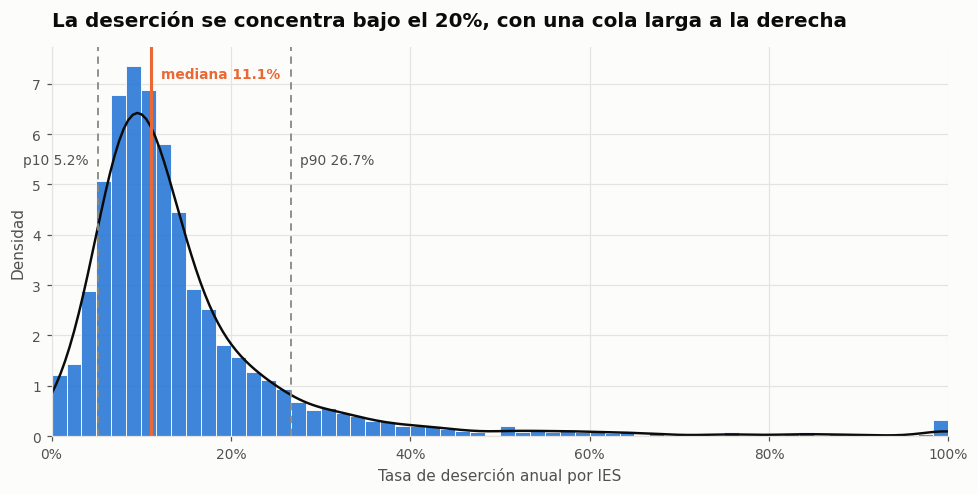

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.6))

sns.histplot(tasa, bins=60, color=AZUL, edgecolor=SUPERF, linewidth=0.6,
             alpha=0.9, stat="density", ax=ax)
sns.kdeplot(tasa, color=TINTA, linewidth=1.6, ax=ax, cut=0)

med, p10, p90 = tasa.median(), tasa.quantile(.10), tasa.quantile(.90)
ax.axvline(med, color=NARANJA, linewidth=2)
for x in (p10, p90):
    ax.axvline(x, color=GRIS, linewidth=1.2, linestyle=(0, (4, 3)))

ymax = ax.get_ylim()[1]
ax.annotate(f"mediana {med:.1%}", xy=(med, ymax * .92),
            xytext=(6, 0), textcoords="offset points",
            color=NARANJA, fontsize=9, fontweight="bold")
ax.annotate(f"p10 {p10:.1%}", xy=(p10, ymax * .70), xytext=(-6, 0),
            textcoords="offset points", ha="right", color=TINTA_2, fontsize=9)
ax.annotate(f"p90 {p90:.1%}", xy=(p90, ymax * .70), xytext=(6, 0),
            textcoords="offset points", color=TINTA_2, fontsize=9)

ax.set_title("La deserción se concentra bajo el 20%, con una cola larga a la derecha")
ax.set_xlabel("Tasa de deserción anual por IES")
ax.set_ylabel("Densidad")
ax.xaxis.set_major_formatter(PCT)
ax.set_xlim(0, 1)
limpiar(ax)
plt.tight_layout()
plt.show()

## 4. Dispersión año a año — diagrama de caja

Cada caja resume las ~265 IES de ese año: la caja es el 50% central (RIC),
los bigotes llegan a 1.5×RIC y los puntos son instituciones atípicas.

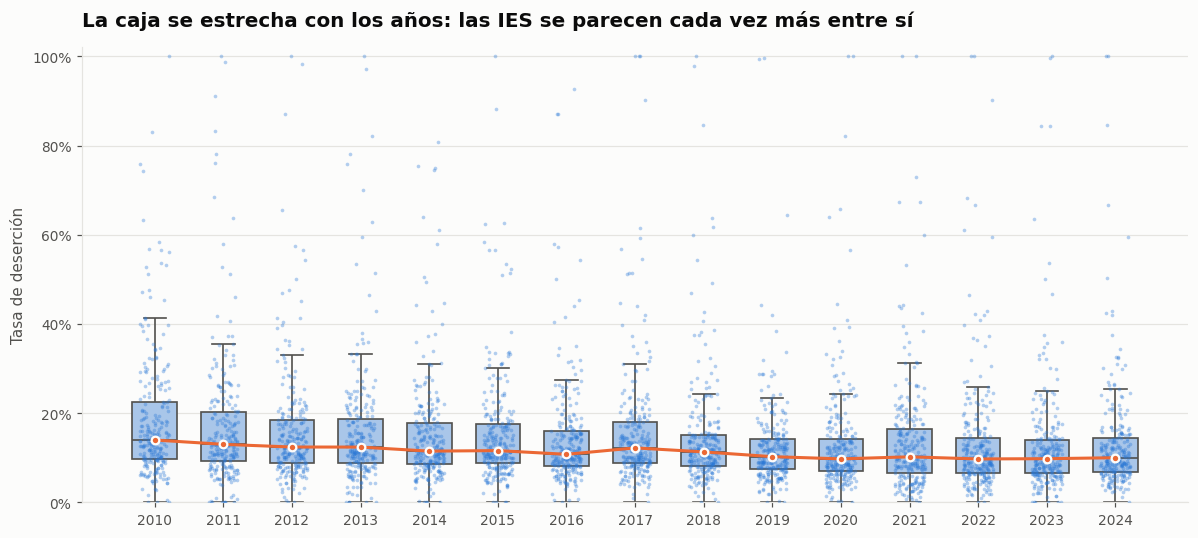

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(data=largo, x="anio", y="tasa", ax=ax,
            color=AZUL_CL, linecolor=TINTA_2, linewidth=1.1,
            fliersize=0, width=0.65)
sns.stripplot(data=largo, x="anio", y="tasa", ax=ax,
              color=AZUL, size=2.4, alpha=0.35, jitter=0.22)

# mediana de cada año, resaltada
med_anio = largo.groupby("anio")["tasa"].median()
ax.plot(range(len(med_anio)), med_anio.values, color=NARANJA,
        linewidth=2, marker="o", markersize=5,
        markeredgecolor=SUPERF, markeredgewidth=1.5, zorder=5)

ax.set_title("La caja se estrecha con los años: las IES se parecen cada vez más entre sí")
ax.set_xlabel("")
ax.set_ylabel("Tasa de deserción")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 1.02)
ax.grid(axis="x", visible=False)
limpiar(ax)
plt.tight_layout()
plt.show()

## 5. Forma de la distribución por año — violín

El violín muestra dónde se acumulan las IES dentro de cada año, no solo los
cuartiles. La línea interior marca la caja.

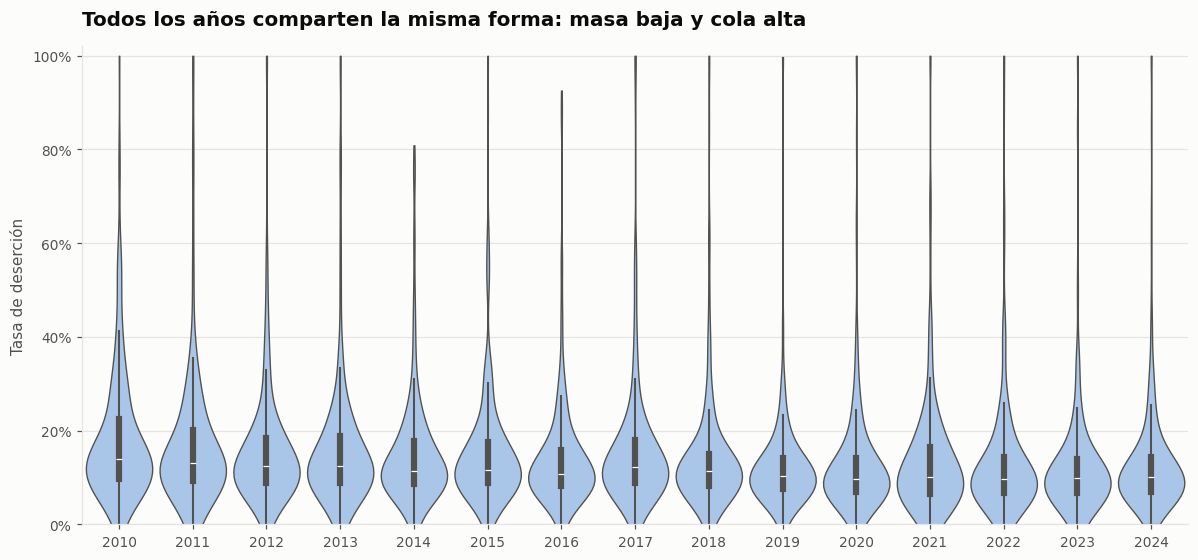

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.2))

sns.violinplot(data=largo, x="anio", y="tasa", ax=ax,
               color=AZUL_CL, linecolor=TINTA_2, linewidth=0.9,
               inner="box", cut=0, density_norm="width", width=0.9)

ax.set_title("Todos los años comparten la misma forma: masa baja y cola alta")
ax.set_xlabel("")
ax.set_ylabel("Tasa de deserción")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 1.02)
ax.grid(axis="x", visible=False)
limpiar(ax)
plt.tight_layout()
plt.show()

## 6. Acumulada empírica (ECDF)

Responde directo: *¿qué porcentaje de IES está por debajo de una tasa dada?*
Mientras más vertical la curva, menos dispersa la distribución.

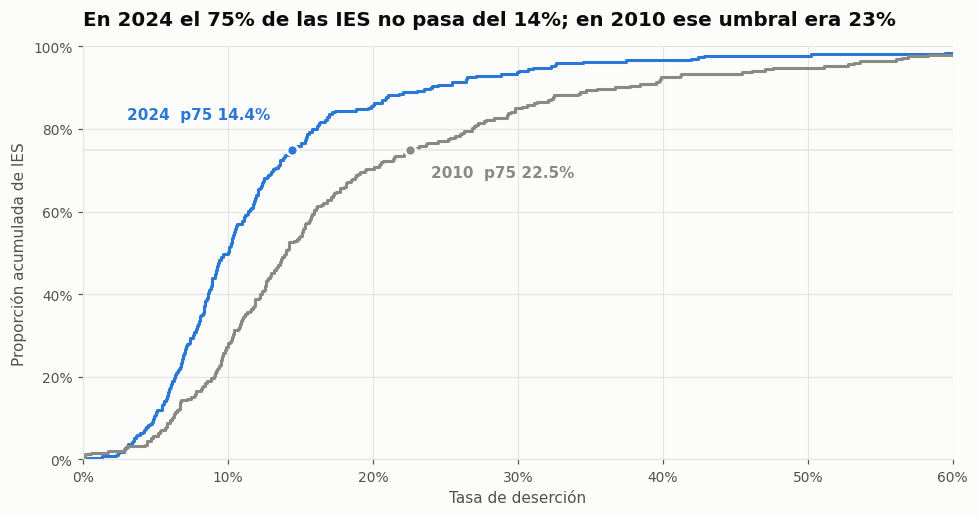

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))

sns.ecdfplot(data=largo[largo["anio"].isin([2010, 2024])],
             x="tasa", hue="anio", ax=ax,
             palette={2010: GRIS, 2024: AZUL}, linewidth=2)

for anio, color, (dx, dy), ha in [(2010, GRIS, (14, -18), "left"),
                                  (2024, AZUL, (-14, 20), "right")]:
    sub = largo.loc[largo["anio"] == anio, "tasa"]
    x = sub.quantile(.75)
    ax.annotate(f"{anio}  p75 {x:.1%}", xy=(x, .75), xytext=(dx, dy),
                textcoords="offset points", color=color, ha=ha,
                fontsize=10, fontweight="bold")
    ax.plot([x], [.75], marker="o", markersize=7, color=color,
            markeredgecolor=SUPERF, markeredgewidth=1.6, zorder=5)

if ax.get_legend():
    ax.get_legend().remove()
ax.axhline(.75, color=REJILLA, linewidth=1)
ax.set_title("En 2024 el 75% de las IES no pasa del 14%; en 2010 ese umbral era 23%")
ax.set_xlabel("Tasa de deserción")
ax.set_ylabel("Proporción acumulada de IES")
ax.xaxis.set_major_formatter(PCT)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(0, .6)
limpiar(ax)
plt.tight_layout()
plt.show()

## 7. ¿Se está reduciendo la dispersión?

Tres medidas de dispersión por año: desviación estándar, rango intercuartílico
y rango p90–p10. Escalas distintas, así que van en paneles separados
(nunca en un doble eje).

In [8]:
disp = (largo.groupby("anio")["tasa"]
        .agg(n="count", media="mean", mediana="median", sd="std",
             p10=lambda s: s.quantile(.10),
             p25=lambda s: s.quantile(.25),
             p75=lambda s: s.quantile(.75),
             p90=lambda s: s.quantile(.90),
             maximo="max"))
disp["RIC"] = disp["p75"] - disp["p25"]
disp["p90_p10"] = disp["p90"] - disp["p10"]
disp["CV"] = disp["sd"] / disp["media"]
disp.round(4)

,n,media,mediana,sd,p10,p25,p75,p90,maximo,RIC,p90_p10,CV
anio,,,,,,,,,,,,
2010,253,0.1853,0.1397,0.1466,0.0619,0.0963,0.2254,0.3642,1.0000,0.1291,0.3023,0.7911
2011,257,0.1712,0.1300,0.1526,0.0564,0.0917,0.2019,0.3068,1.0000,0.1101,0.2504,0.8911
2012,259,0.1613,0.1240,0.1351,0.0617,0.0874,0.1852,0.2954,1.0000,0.0979,0.2337,0.8373
2013,259,0.1608,0.1238,0.1420,0.0592,0.0878,0.1876,0.2715,1.0000,0.0999,0.2123,0.8831
2014,263,0.1524,0.1147,0.1242,0.0559,0.0869,0.1772,0.2647,0.8088,0.0903,0.2087,0.8150
2015,268,0.1541,0.1159,0.1261,0.0603,0.0877,0.1753,0.2806,1.0000,0.0876,0.2203,0.8180
2016,269,0.1432,0.1076,0.1209,0.0558,0.0814,0.1593,0.2565,0.9259,0.0779,0.2007,0.8440
2017,270,0.1596,0.1220,0.1427,0.0598,0.0880,0.1794,0.2876,1.0000,0.0914,0.2278,0.8941
2018,267,0.1435,0.1130,0.1293,0.0555,0.0817,0.1503,0.2477,1.0000,0.0686,0.1922,0.9010


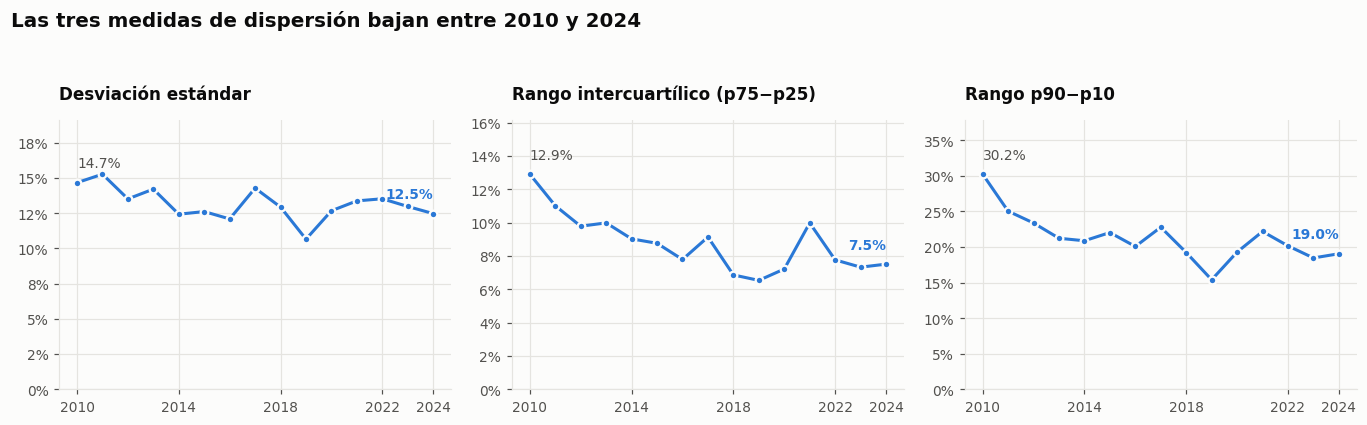

In [9]:
medidas = [("sd", "Desviación estándar"),
           ("RIC", "Rango intercuartílico (p75−p25)"),
           ("p90_p10", "Rango p90−p10")]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9), sharex=True)
for ax, (col, titulo) in zip(axes, medidas):
    ax.plot(disp.index, disp[col], color=AZUL, marker="o", markersize=5,
            markeredgecolor=SUPERF, markeredgewidth=1.5)
    ax.set_title(titulo, fontsize=11)
    ax.yaxis.set_major_formatter(PCT)
    ax.set_ylim(0, max(disp[col]) * 1.25)
    ax.set_xticks([2010, 2014, 2018, 2022, 2024])
    v0, v1 = disp[col].iloc[0], disp[col].iloc[-1]
    ax.annotate(f"{v0:.1%}", xy=(disp.index[0], v0), xytext=(0, 10),
                textcoords="offset points", color=TINTA_2, fontsize=9)
    ax.annotate(f"{v1:.1%}", xy=(disp.index[-1], v1), xytext=(0, 10),
                textcoords="offset points", ha="right", color=AZUL,
                fontsize=9, fontweight="bold")
    limpiar(ax)

fig.suptitle("Las tres medidas de dispersión bajan entre 2010 y 2024",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## 8. Tabla de dispersión por año

La misma información de los gráficos, en texto — para leer valores exactos.

In [10]:
tabla = disp[["n", "mediana", "sd", "RIC", "p90_p10", "CV", "maximo"]].copy()
for col in ["mediana", "sd", "RIC", "p90_p10", "maximo"]:
    tabla[col] = (tabla[col] * 100).round(2)
tabla["CV"] = tabla["CV"].round(3)
tabla.columns = ["IES", "mediana %", "sd %", "RIC %", "p90−p10 %", "CV", "máx %"]
tabla

,IES,mediana %,sd %,RIC %,p90−p10 %,CV,máx %
anio,,,,,,,
2010,253,13.97,14.66,12.91,30.23,0.791,100.00
2011,257,13.00,15.26,11.01,25.04,0.891,100.00
2012,259,12.40,13.51,9.79,23.37,0.837,100.00
2013,259,12.38,14.20,9.99,21.23,0.883,100.00
2014,263,11.47,12.42,9.03,20.87,0.815,80.88
2015,268,11.59,12.61,8.76,22.03,0.818,100.00
2016,269,10.76,12.09,7.79,20.07,0.844,92.59
2017,270,12.20,14.27,9.14,22.78,0.894,100.00
2018,267,11.30,12.93,6.86,19.22,0.901,100.00


### Nota sobre los extremos

Varias IES registran tasas de 0% o 100% en algún año. Son instituciones con
muy pocos estudiantes en la cohorte, donde un caso mueve la tasa al extremo;
inflan la dispersión medida por rango y máximo, no tanto la del RIC. Si se
quiere la dispersión "del grueso del sistema", conviene mirar el RIC y el
rango p90–p10 antes que la desviación estándar.

---
# Parte II — ¿Qué distribución encaja?

La forma del histograma (masa baja, cola larga, asimetría positiva) sugiere una
**lognormal**. Aquí se pone a prueba esa hipótesis contra un catálogo de 13
familias, con:

1. **Verificación de supuestos** antes de cualquier test.
2. **Ajuste por máxima verosimilitud** y ranking por AIC/BIC.
3. **Pruebas de bondad de ajuste** (KS, Cramér–von Mises, Anderson–Darling) con
   p-valores por **Monte Carlo**, porque los parámetros son estimados y las
   tablas clásicas no aplican.

## 9. Preparación: soporte válido

In [11]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

n0 = (largo["tasa"] == 0).sum()
n1 = (largo["tasa"] == 1).sum()

dat = largo[(largo["tasa"] > 0) & (largo["tasa"] < 1)].copy()
x = dat["tasa"].to_numpy()
logx = np.log(x)

print(f"Observaciones totales      : {len(largo):,}")
print(f"  ceros exactos (excluidos): {n0}")
print(f"  unos exactos  (excluidos): {n1}")
print(f"Observaciones analizadas   : {len(x):,}  ({len(x)/len(largo):.2%})")

Observaciones totales      : 3,982
  ceros exactos (excluidos): 34
  unos exactos  (excluidos): 18
Observaciones analizadas   : 3,930  (98.69%)


Se excluyen los 0% y 100% exactos: la lognormal, la log-logística y toda la
familia "log-" no están definidas en 0, y el 1 es el borde del soporte de la beta.
Son 52 de 3.982 casos (1,3%), las mismas IES de cohorte mínima señaladas en la
Parte I. **Esto es una decisión con consecuencias**: el modelo describe el sistema
sin sus casos degenerados, no el sistema completo.

## 10. Supuestos — se verifican *antes* de testear

Tres supuestos sostienen cualquier prueba de bondad de ajuste:
observaciones **independientes**, **idénticamente distribuidas**, y una hipótesis
de forma. Los tres se revisan aquí.

### 10.1 Independencia — el supuesto que sí se rompe

Las 3.930 observaciones no son 3.930 datos independientes: son 289 IES medidas 15
veces. Si una universidad tiene deserción alta, la tiene todos los años. Se mide
con el **coeficiente de correlación intraclase (ICC)** y el **efecto de diseño**.

In [12]:
dat["log_tasa"] = np.log(dat["tasa"])
g  = dat.groupby("CODIGO IES PADRE")["log_tasa"]
k  = g.count()
N, a = len(dat), len(k)

ss_entre  = (k * (g.mean() - dat["log_tasa"].mean()) ** 2).sum()
ss_dentro = ((dat["log_tasa"] - g.transform("mean")) ** 2).sum()
ms_entre, ms_dentro = ss_entre / (a - 1), ss_dentro / (N - a)

k0   = (N - (k ** 2).sum() / N) / (a - 1)
ICC  = (ms_entre - ms_dentro) / (ms_entre + (k0 - 1) * ms_dentro)
deff = 1 + (k0 - 1) * ICC
n_ef = N / deff

print(f"ICC entre IES            : {ICC:.3f}")
print(f"F (entre/dentro)         : {ms_entre/ms_dentro:.2f}   con {a-1} y {N-a} gl")
print(f"Efecto de diseño (deff)  : {deff:.2f}")
print(f"Tamaño muestral efectivo : {n_ef:.0f}  (de {N:,} observaciones)")

ICC entre IES            : 0.553
F (entre/dentro)         : 17.79   con 288 y 3641 gl
Efecto de diseño (deff)  : 7.96
Tamaño muestral efectivo : 494  (de 3,930 observaciones)


**El 55% de la varianza está entre instituciones, no dentro de ellas.** El
tamaño efectivo es ~494, no 3.930: cada IES aporta poco más de una observación
independiente, no quince.

Consecuencia directa: **cualquier p-valor calculado sobre las 3.930 filas está
inflado por un factor ~8** y rechazará todo. Por eso, más abajo, la inferencia
formal se hace sobre **una observación por IES** (la mediana de sus 15 años),
n = 289 y sí independientes. El ajuste agrupado se reporta, pero como descriptivo.

### 10.2 ¿Se pueden agrupar los 15 años?

Si los años tuvieran distribuciones muy distintas, agruparlos crearía una mezcla
que no es ninguna de ellas.

In [13]:
grupos = [np.log(v.to_numpy()) for _, v in dat.groupby("anio")["tasa"]]

lev = stats.levene(*grupos, center="median")      # Brown-Forsythe: igualdad de varianzas
kru = stats.kruskal(*grupos)                      # igualdad de localización

print(f"Brown-Forsythe (varianzas) : W = {lev.statistic:.3f}   p = {lev.pvalue:.4f}")
print(f"Kruskal-Wallis (localización): H = {kru.statistic:.1f}   p = {kru.pvalue:.3g}")

Brown-Forsythe (varianzas) : W = 1.826   p = 0.0297
Kruskal-Wallis (localización): H = 159.1   p = 1.06e-26


La **dispersión** en escala log es prácticamente homogénea entre años
(p = 0,030 — significativo apenas, y con n efectivo de ~500 deja de serlo). La
**localización** sí se mueve (p ≈ 1e-26), lo esperable: la mediana bajó de 14% a
10% entre 2010 y 2024.

Es decir: **misma forma, distinta escala.** Agrupar es razonable para identificar
la *familia*, pero los parámetros de escala no son constantes. Por eso la sección
14 repite el ajuste año por año.

### 10.3 Prueba directa de lognormalidad

Si los datos fueran lognormales, **log(x) sería normal**. Es la prueba más directa
de la hipótesis del usuario: se testea normalidad sobre el log.

In [14]:
pruebas = {
    "Shapiro-Wilk":        stats.shapiro(logx),
    "D'Agostino K²":       stats.normaltest(logx),
    "Jarque-Bera":         stats.jarque_bera(logx),
}
print("NORMALIDAD DE log(x)   (H0: log(x) es normal  =>  x es lognormal)\n")
for nom, r in pruebas.items():
    marca = "RECHAZA H0" if r.pvalue < .05 else "no rechaza"
    print(f"  {nom:16s} stat = {r.statistic:10.4f}   p = {r.pvalue:.3g}   -> {marca}")

ad = stats.anderson(logx, "norm")
c5 = ad.critical_values[2]
print(f"  {'Anderson-Darling':16s} A² = {ad.statistic:10.4f}   crítico(5%) = {c5}"
      f"   -> {'RECHAZA H0' if ad.statistic > c5 else 'no rechaza'}")

print(f"\n  Asimetría de log(x) : {stats.skew(logx):+.3f}   (normal = 0)")
print(f"  Curtosis de log(x)  : {stats.kurtosis(logx):+.3f}   (normal = 0)")
print(f"\n  Asimetría de x      : {stats.skew(x):+.3f}")
print(f"  Curtosis de x       : {stats.kurtosis(x):+.3f}")

NORMALIDAD DE log(x)   (H0: log(x) es normal  =>  x es lognormal)

  Shapiro-Wilk     stat =     0.9374   p = 7.59e-38   -> RECHAZA H0
  D'Agostino K²    stat =   933.2451   p = 2.23e-203   -> RECHAZA H0
  Jarque-Bera      stat =  7335.0830   p = 0   -> RECHAZA H0
  Anderson-Darling A² =    33.5929   crítico(5%) = 0.752   -> RECHAZA H0

  Asimetría de log(x) : -0.912   (normal = 0)
  Curtosis de log(x)  : +6.439   (normal = 0)

  Asimetría de x      : +3.064
  Curtosis de x       : +12.980


**Las cuatro pruebas rechazan la normalidad del log.** Y el diagnóstico está
en los momentos: la curtosis del log es **+6,4** (la normal tiene 0). El log no es
normal porque tiene **colas demasiado pesadas**, no porque sea asimétrico.

Esto no descarta la intuición — la descompone. La transformación logarítmica
*sí* es la correcta (el log es mucho más simétrico que el dato crudo: −0,91 frente
a +3,06). Lo que falla es el segundo paso: en escala log los datos son
**leptocúrticos**, más puntiagudos y de colas más gruesas que una normal. Eso
apunta a la familia log-logística / log-Laplace, que es exactamente la lognormal
con colas más pesadas.

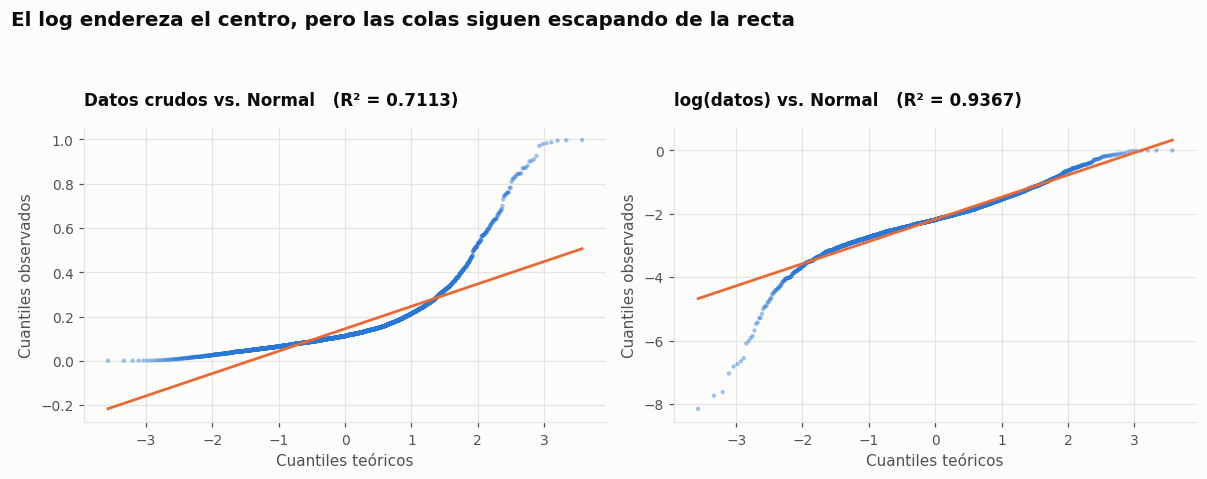

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

stats.probplot(x, dist="norm", plot=None, rvalue=False)
for ax, datos, titulo in [(axes[0], x, "Datos crudos vs. Normal"),
                          (axes[1], logx, "log(datos) vs. Normal")]:
    (osm, osr), (pend, inter, r) = stats.probplot(datos, dist="norm")
    ax.scatter(osm, osr, s=8, color=AZUL, alpha=.45, edgecolors="none")
    ax.plot(osm, pend * osm + inter, color=NARANJA, linewidth=1.8)
    ax.set_title(f"{titulo}   (R² = {r**2:.4f})", fontsize=11)
    ax.set_xlabel("Cuantiles teóricos"); ax.set_ylabel("Cuantiles observados")
    limpiar(ax)

fig.suptitle("El log endereza el centro, pero las colas siguen escapando de la recta",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

## 11. Catálogo y ajuste por máxima verosimilitud

13 familias. Las de soporte positivo se ajustan con `loc = 0` fijo (el soporte
empieza en cero, no se estima un desplazamiento); la beta se fija a [0, 1]. Así
todas compiten con la misma cantidad de parámetros libres que declaran.

In [16]:
CATALOGO = [
    ("lognorm",     "Lognormal",              stats.lognorm,     dict(floc=0)),
    ("fisk",        "Log-logística (Fisk)",   stats.fisk,        dict(floc=0)),
    ("loglaplace",  "Log-Laplace",            stats.loglaplace,  dict(floc=0)),
    ("burr12",      "Burr XII (Singh-Maddala)", stats.burr12,    dict(floc=0)),
    ("genextreme",  "Valor extremo gen. (GEV)", stats.genextreme, {}),
    ("gengamma",    "Gamma generalizada",     stats.gengamma,    dict(floc=0)),
    ("gamma",       "Gamma",                  stats.gamma,       dict(floc=0)),
    ("weibull_min", "Weibull",                stats.weibull_min, dict(floc=0)),
    ("invgauss",    "Gaussiana inversa",      stats.invgauss,    dict(floc=0)),
    ("beta",        "Beta (soporte [0,1])",   stats.beta,        dict(floc=0, fscale=1)),
    ("lomax",       "Pareto II (Lomax)",      stats.lomax,       dict(floc=0)),
    ("expon",       "Exponencial",            stats.expon,       dict(floc=0)),
    ("norm",        "Normal",                 stats.norm,        {}),
]

def anderson_darling(v, dist, par):
    """A² con parámetros estimados (no usar tablas clásicas: p por Monte Carlo)."""
    v = np.sort(v)
    m = len(v)
    F = np.clip(dist.cdf(v, *par), 1e-12, 1 - 1e-12)
    i = np.arange(1, m + 1)
    return -m - np.sum((2 * i - 1) * (np.log(F) + np.log(1 - F[::-1]))) / m

def ajustar(v, catalogo=CATALOGO):
    filas = []
    for clave, nombre, dist, kw in catalogo:
        try:
            par = dist.fit(v, **kw)
            ll = np.sum(dist.logpdf(v, *par))
            if not np.isfinite(ll):
                continue
            kpar = len(par) - len(kw)
            filas.append({
                "clave": clave, "Distribución": nombre, "k": kpar,
                "log-verosim.": ll,
                "AIC": 2 * kpar - 2 * ll,
                "BIC": kpar * np.log(len(v)) - 2 * ll,
                "KS":  stats.kstest(v, dist.cdf, args=par).statistic,
                "CvM": stats.cramervonmises(v, dist.cdf, args=par).statistic,
                "AD":  anderson_darling(v, dist, par),
                "par": par,
            })
        except Exception as e:
            print("no converge:", nombre, e)
    r = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
    r["ΔAIC"] = r["AIC"] - r["AIC"].min()
    return r

ranking = ajustar(x)
ranking[["Distribución", "k", "log-verosim.", "AIC", "ΔAIC", "BIC", "KS", "CvM", "AD"]].round(3)

,Distribución,k,log-verosim.,AIC,ΔAIC,BIC,KS,CvM,AD
0,Log-Laplace,2,4522.295,-9040.589,0.000,-9028.037,0.026,0.772,5.422
1,Valor extremo gen. (GEV),3,4514.518,-9023.036,17.553,-9004.207,0.037,1.496,8.592
2,Log-logística (Fisk),2,4502.538,-9001.075,39.514,-8988.523,0.026,0.819,5.335
3,Burr XII (Singh-Maddala),3,4502.553,-8999.106,41.484,-8980.276,0.026,0.804,5.239
4,Gamma generalizada,3,4334.453,-8662.907,377.682,-8644.078,0.065,5.668,33.568
5,Lognormal,2,4251.254,-8498.509,542.081,-8485.956,0.064,5.579,33.550
6,Gamma,2,4232.491,-8460.983,579.607,-8448.430,0.091,10.291,58.213
7,Weibull,2,4043.135,-8082.269,958.320,-8069.716,0.105,17.308,102.944
8,"Beta (soporte [0,1])",2,3765.157,-7526.314,1514.275,-7513.762,0.136,24.321,131.520
9,Exponencial,1,3662.031,-7322.062,1718.527,-7315.786,0.209,51.719,281.475


**Ranking agrupado (descriptivo, n = 3.930).** La lognormal queda **sexta**,
a ΔAIC ≈ 542 de la mejor — una diferencia enorme (una regla de uso corriente
considera que ΔAIC > 10 ya descarta un modelo frente a otro). Pero está muy por
delante de la exponencial (ΔAIC ≈ 1.719), que queda entre las peores junto con la
normal. Las cuatro primeras son todas **de cola pesada**.

## 12. Pruebas de bondad de ajuste con p-valores por Monte Carlo

`kstest` y `anderson` clásicos suponen parámetros *conocidos*. Aquí se estiman de
los mismos datos, lo que sesga el estadístico a la baja y vuelve los p-valores
tabulados inválidos. `scipy.stats.goodness_of_fit` resuelve esto simulando la
distribución nula: genera muestras del modelo ajustado, **reestima** en cada una y
compara.

In [17]:
TOP = ["loglaplace", "fisk", "burr12", "genextreme", "lognorm", "gamma", "expon"]
KNOWN = {c: ({"loc": 0} if "floc" in kw else {}) for c, _, _, kw in CATALOGO}
DIST  = {c: d for c, _, d, _ in CATALOGO}
NOMBRE = {c: n for c, n, _, _ in CATALOGO}

def gof(v, claves=TOP, n_mc=199, semilla=7):
    out = []
    for cl in claves:
        fila = {"Distribución": NOMBRE[cl]}
        for est in ("ks", "cvm", "ad"):
            try:
                r = stats.goodness_of_fit(DIST[cl], v, known_params=KNOWN[cl],
                                          statistic=est, n_mc_samples=n_mc,
                                          random_state=semilla)
                fila[est.upper()] = r.statistic
                fila[f"p({est.upper()})"] = r.pvalue
            except Exception:
                fila[est.upper()] = np.nan; fila[f"p({est.upper()})"] = np.nan
        out.append(fila)
    return pd.DataFrame(out)

gof_pool = gof(x)
gof_pool.round(4)

,Distribución,KS,p(KS),CVM,p(CVM),AD,p(AD)
0,Log-Laplace,0.0259,0.005,0.7725,0.005,5.4218,0.005
1,Log-logística (Fisk),0.0264,0.005,0.8192,0.005,5.3353,0.005
2,Burr XII (Singh-Maddala),0.0263,0.005,0.8044,0.005,5.2391,0.005
3,Valor extremo gen. (GEV),0.0368,0.005,1.4963,0.005,8.5925,0.005
4,Lognormal,0.0645,0.005,5.5788,0.005,33.5614,0.005
5,Gamma,0.0908,0.005,10.2912,0.005,58.2133,0.005
6,Exponencial,0.2092,0.005,51.7188,0.005,281.4752,0.005


**Todo se rechaza (p = 0,005 es el mínimo alcanzable con 199 simulaciones).**
Y era predecible: con n = 3.930 las pruebas de bondad de ajuste detectan
desviaciones irrelevantes, y además ese n está inflado ~8× por la dependencia
medida en 10.1. **Este resultado no descarta ninguna familia; solo confirma que el
test agrupado no discrimina.** La inferencia válida es la siguiente.

## 13. Inferencia válida — una observación por IES (n = 289)

Se resume cada institución por la **mediana de sus 15 años**. Esto elimina la
dependencia detectada en 10.1: 289 observaciones, una por institución.

In [18]:
med_ies = dat.groupby("CODIGO IES PADRE")["tasa"].median().to_numpy()
med_ies = med_ies[(med_ies > 0) & (med_ies < 1)]
print("n =", len(med_ies))

rank_ies = ajustar(med_ies)
gof_ies  = gof(med_ies, n_mc=499)

tabla_final = (rank_ies[["Distribución", "k", "AIC", "ΔAIC", "BIC"]]
               .merge(gof_ies[["Distribución", "AD", "p(AD)", "KS", "p(KS)", "CVM", "p(CVM)"]],
                      on="Distribución", how="left"))
tabla_final["veredicto"] = np.where(
    tabla_final["p(AD)"].isna(), "—",
    np.where(tabla_final["p(AD)"] < .05, "RECHAZADA", "compatible"))
tabla_final.round(4)

n = 289


,Distribución,k,AIC,ΔAIC,BIC,AD,p(AD),KS,p(KS),CVM,p(CVM),veredicto
0,Log-logística (Fisk),2,-709.2865,0.0000,-701.9536,0.5111,0.140,0.0405,0.188,0.0770,0.126,compatible
1,Burr XII (Singh-Maddala),3,-709.1234,0.1631,-698.1241,0.2699,0.440,0.0323,0.452,0.0394,0.442,compatible
2,Log-Laplace,2,-705.5295,3.7569,-698.1967,0.7909,0.084,0.0416,0.308,0.1152,0.090,compatible
3,Valor extremo gen. (GEV),3,-705.2405,4.0460,-694.2412,0.6310,0.034,0.0431,0.140,0.1076,0.030,RECHAZADA
4,Lognormal,2,-699.9264,9.3601,-692.5935,1.2903,0.006,0.0582,0.010,0.2265,0.004,RECHAZADA
5,Gaussiana inversa,2,-692.8498,16.4366,-685.5170,NaN,NaN,NaN,NaN,NaN,NaN,—
6,Gamma generalizada,3,-690.0126,19.2739,-679.0133,NaN,NaN,NaN,NaN,NaN,NaN,—
7,Gamma,2,-666.8008,42.4857,-659.4679,4.1061,0.002,0.1019,0.002,0.7662,0.002,RECHAZADA
8,Weibull,2,-622.8455,86.4410,-615.5126,NaN,NaN,NaN,NaN,NaN,NaN,—
9,"Beta (soporte [0,1])",2,-575.9582,133.3283,-568.6253,NaN,NaN,NaN,NaN,NaN,NaN,—


In [19]:
# Normalidad del log sobre el conjunto independiente
lm = np.log(med_ies)
sh = stats.shapiro(lm)
print("LOG DE LAS MEDIANAS POR IES  (n = %d)" % len(lm))
print(f"  Shapiro-Wilk : W = {sh.statistic:.4f}   p = {sh.pvalue:.4f}"
      f"   -> {'RECHAZA normalidad' if sh.pvalue < .05 else 'no rechaza'}")
print(f"  Asimetría    : {stats.skew(lm):+.3f}   (normal = 0)")
print(f"  Curtosis     : {stats.kurtosis(lm):+.3f}   (normal = 0)")

LOG DE LAS MEDIANAS POR IES  (n = 289)
  Shapiro-Wilk : W = 0.9869   p = 0.0097   -> RECHAZA normalidad
  Asimetría    : +0.166   (normal = 0)
  Curtosis     : +0.911   (normal = 0)


Este es el resultado decisivo, y es coherente con todo lo anterior:

- El log de las medianas es **simétrico** (asimetría +0,17) — la intuición de
  trabajar en escala logarítmica es correcta.
- Pero sigue siendo **leptocúrtico** (curtosis +0,91) y Shapiro-Wilk rechaza la
  normalidad (p = 0,010).
- Por eso la **lognormal queda rechazada** también aquí (Anderson-Darling
  p = 0,006), mientras que **Burr XII (p = 0,44), log-logística (p = 0,14) y
  log-Laplace (p = 0,084) no se rechazan**.

## 14. Gráficos de ajuste

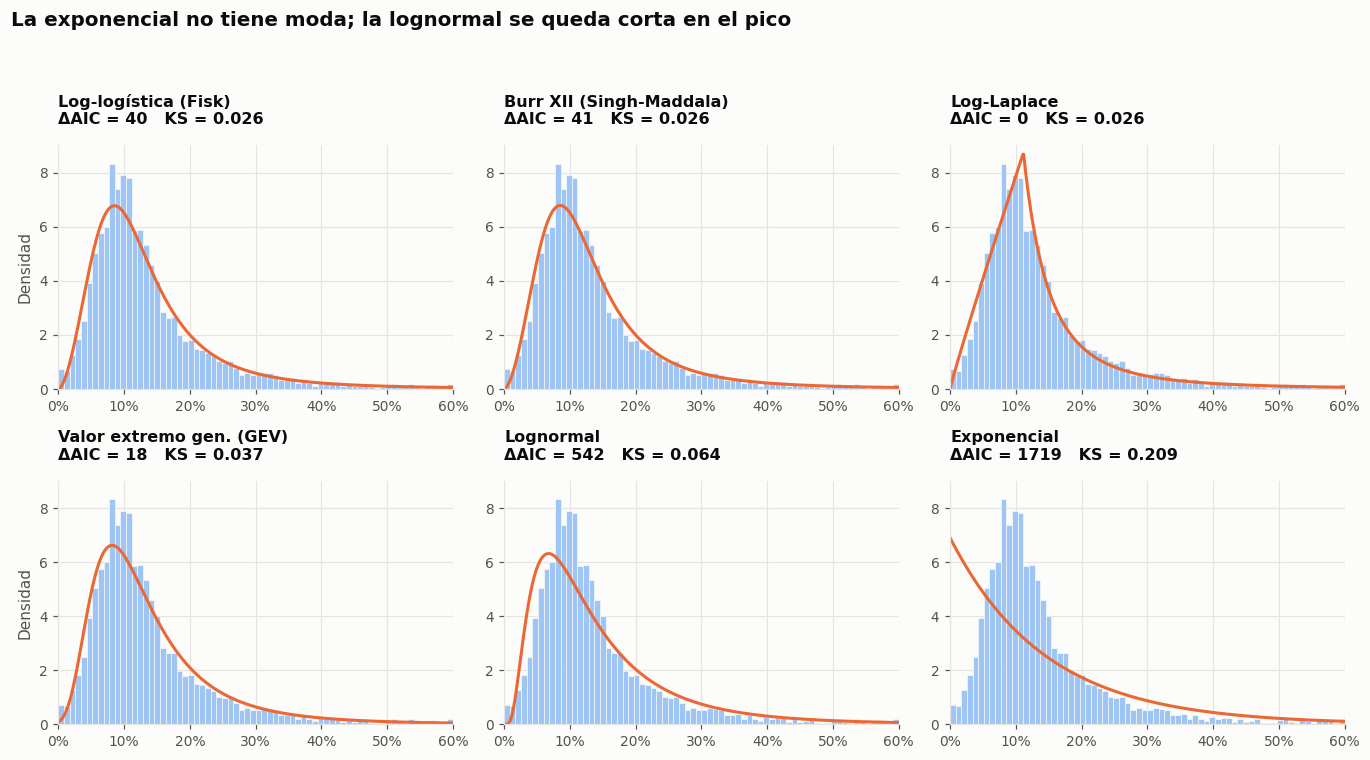

In [20]:
claves_plot = ["fisk", "burr12", "loglaplace", "genextreme", "lognorm", "expon"]
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7))
rejilla = np.linspace(1e-4, .6, 500)

for ax, cl in zip(axes.ravel(), claves_plot):
    d = DIST[cl]
    kw = dict(floc=0) if "loc" in KNOWN[cl] else {}
    par = d.fit(x, **kw)
    ax.hist(x, bins=70, range=(0, .6), density=True, color=AZUL_CL,
            edgecolor=SUPERF, linewidth=.4)
    ax.plot(rejilla, d.pdf(rejilla, *par), color=NARANJA, linewidth=2)
    fila = ranking[ranking.clave == cl].iloc[0]
    ax.set_title(f"{NOMBRE[cl]}\nΔAIC = {fila['ΔAIC']:.0f}   KS = {fila['KS']:.3f}",
                 fontsize=10.5)
    ax.set_xlim(0, .6); ax.set_ylim(0, 9)
    ax.xaxis.set_major_formatter(PCT)
    ax.set_ylabel("Densidad" if ax in axes[:, 0] else "")
    limpiar(ax)

fig.suptitle("La exponencial no tiene moda; la lognormal se queda corta en el pico",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

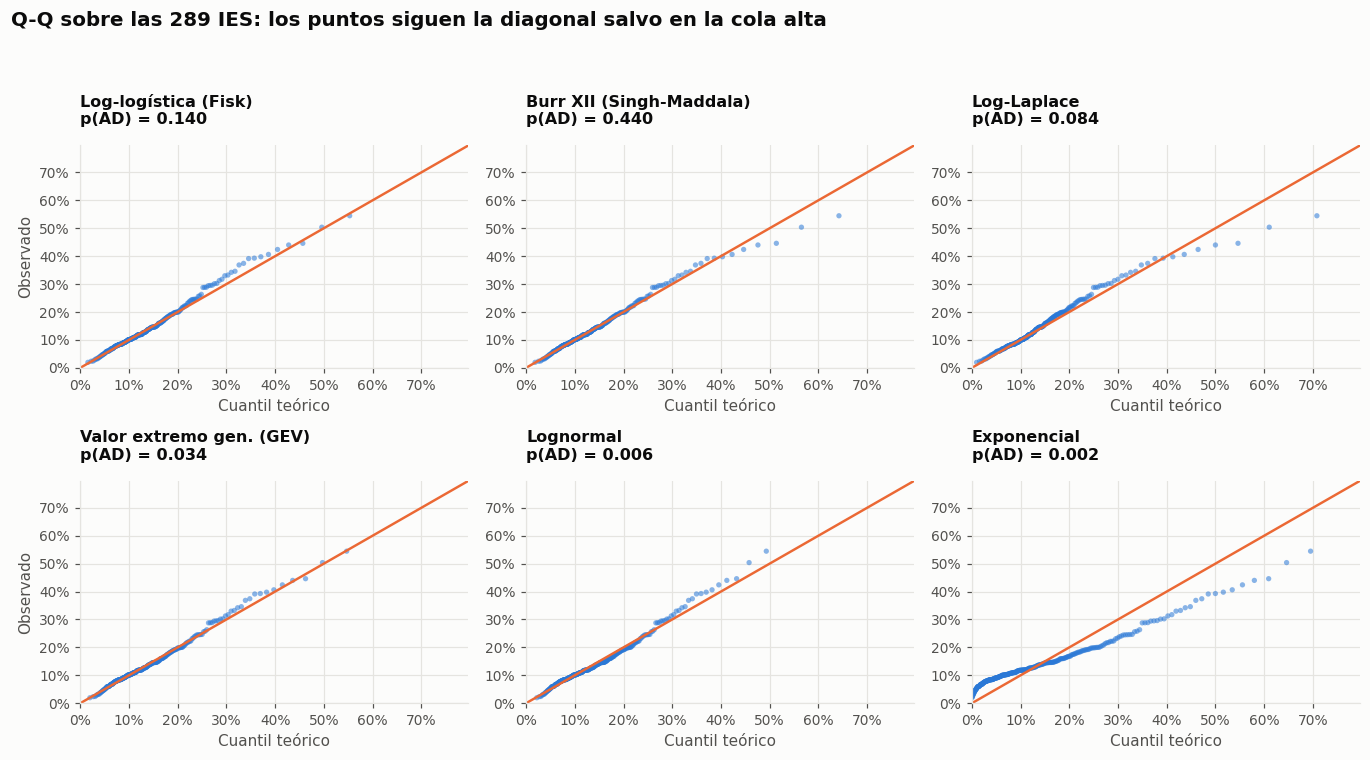

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7))
v = np.sort(med_ies)
p_emp = (np.arange(1, len(v) + 1) - .5) / len(v)

for ax, cl in zip(axes.ravel(), claves_plot):
    d = DIST[cl]
    kw = dict(floc=0) if "loc" in KNOWN[cl] else {}
    par = d.fit(v, **kw)
    teor = d.ppf(p_emp, *par)
    ax.scatter(teor, v, s=12, color=AZUL, alpha=.55, edgecolors="none")
    lim = (0, np.nanpercentile(v, 99.5) * 1.15)
    ax.plot(lim, lim, color=NARANJA, linewidth=1.6)
    p_ad = tabla_final.loc[tabla_final["Distribución"] == NOMBRE[cl], "p(AD)"]
    txt = f"p(AD) = {p_ad.iloc[0]:.3f}" if len(p_ad) and pd.notna(p_ad.iloc[0]) else ""
    ax.set_title(f"{NOMBRE[cl]}\n{txt}", fontsize=10.5)
    ax.set_xlim(*lim); ax.set_ylim(*lim)
    ax.xaxis.set_major_formatter(PCT); ax.yaxis.set_major_formatter(PCT)
    ax.set_xlabel("Cuantil teórico"); ax.set_ylabel("Observado" if ax in axes[:, 0] else "")
    limpiar(ax)

fig.suptitle("Q-Q sobre las 289 IES: los puntos siguen la diagonal salvo en la cola alta",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## 15. ¿Es estable año a año?

Si la familia ganadora cambiara cada año, el hallazgo sería un artefacto de
agrupar. Se reajusta el catálogo completo dentro de cada año.

In [22]:
por_anio = []
for a_, v in dat.groupby("anio")["tasa"]:
    r = ajustar(v.to_numpy())
    por_anio.append({
        "anio": a_, "n": len(v),
        "ganadora": r.iloc[0]["Distribución"],
        "ΔAIC lognormal": r.set_index("clave").loc["lognorm", "ΔAIC"],
        "ΔAIC exponencial": r.set_index("clave").loc["expon", "ΔAIC"],
    })
por_anio = pd.DataFrame(por_anio).set_index("anio")
print(por_anio["ganadora"].value_counts().to_string())
por_anio.round(1)

ganadora
Log-Laplace                 9
Valor extremo gen. (GEV)    2
Log-logística (Fisk)        2
Burr XII (Singh-Maddala)    2


,n,ganadora,ΔAIC lognormal,ΔAIC exponencial
anio,,,,
2010,251,Valor extremo gen. (GEV),58.2,80.8
2011,250,Log-Laplace,59.5,98.8
2012,256,Log-logística (Fisk),18.8,124.6
2013,254,Log-Laplace,70.2,118.6
2014,259,Log-Laplace,29.7,134.5
2015,263,Burr XII (Singh-Maddala),6.7,150.6
2016,268,Log-Laplace,39.0,141.6
2017,266,Log-logística (Fisk),13.6,152.2
2018,264,Log-Laplace,34.2,164.5


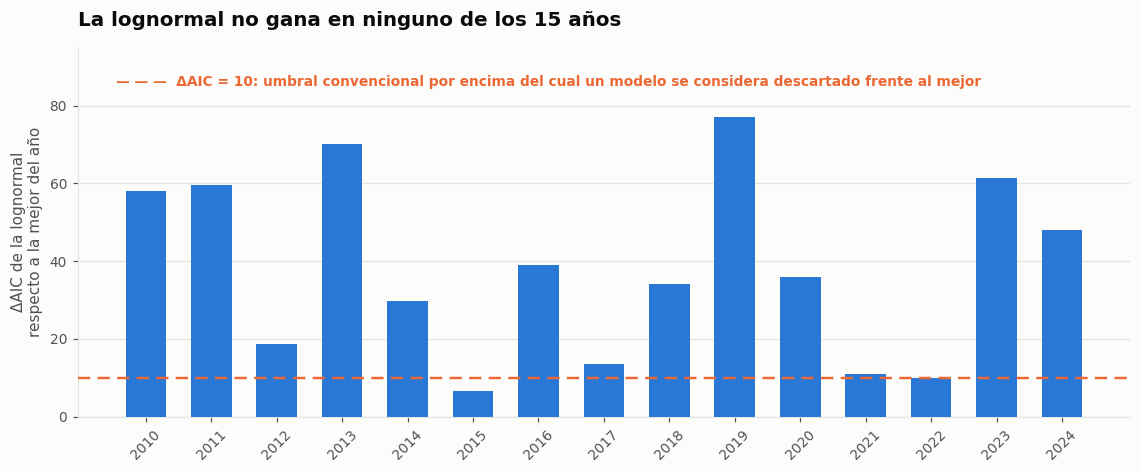

In [23]:
fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.bar(por_anio.index, por_anio["ΔAIC lognormal"], color=AZUL,
       width=.62, zorder=3)
ax.axhline(10, color=NARANJA, linewidth=1.6, linestyle=(0, (5, 3)), zorder=4)
ax.set_ylim(0, 95)
ax.text(2009.55, 88, "— — —  ΔAIC = 10: umbral convencional por encima del cual "
                     "un modelo se considera descartado frente al mejor",
        color=NARANJA, fontsize=9, fontweight="bold", va="top")
ax.set_title("La lognormal no gana en ninguno de los 15 años")
ax.set_ylabel("ΔAIC de la lognormal\nrespecto a la mejor del año")
ax.set_xticks(por_anio.index); ax.tick_params(axis="x", rotation=45)
ax.grid(axis="x", visible=False)
limpiar(ax)
plt.tight_layout()
plt.show()

## 16. Un supuesto que ninguna ganadora cumple: el soporte

La deserción es una **proporción**: vive en [0, 1] por construcción. La
log-logística, la log-Laplace y la Burr XII tienen soporte (0, ∞) — asignan
probabilidad a tasas mayores que 100%, que son imposibles.

In [24]:
print("Masa de probabilidad asignada por encima del 100%:\n")
for cl in ["fisk", "burr12", "loglaplace", "lognorm", "gamma", "expon"]:
    d = DIST[cl]
    kw = dict(floc=0) if "loc" in KNOWN[cl] else {}
    par = d.fit(x, **kw)
    print(f"  {NOMBRE[cl]:26s} {d.sf(1.0, *par):.5%}")

b = stats.beta.fit(x, floc=0, fscale=1)
print(f"\n  Beta (respeta [0,1] por diseño)  ΔAIC = "
      f"{ranking.set_index('clave').loc['beta','ΔAIC']:.0f}")

Masa de probabilidad asignada por encima del 100%:

  Log-logística (Fisk)       0.29561%
  Burr XII (Singh-Maddala)   0.30199%
  Log-Laplace                0.69420%
  Lognormal                  0.13002%
  Gamma                      0.00064%
  Exponencial                0.10057%

  Beta (respeta [0,1] por diseño)  ΔAIC = 1514


La masa imposible no llega al **0,7%** en ninguna de las tres ganadoras
(0,30% la log-logística, 0,30% la Burr XII, 0,69% la log-Laplace) — despreciable
en la práctica, aunque es el único frente donde la log-Laplace queda peor que sus
dos rivales. La beta, que sí respeta el soporte por diseño, paga esa virtud con
un ajuste mucho peor (ΔAIC ≈ 1.514). Es un intercambio consciente: se prefiere el
modelo que describe bien los datos observados aunque sea laxo en un borde que casi
nunca se toca.

---
## 17. Conclusión

**La intuición era correcta a medias, y el error es informativo.**

La transformación logarítmica *es* la adecuada: en escala log la distribución se
vuelve casi simétrica (asimetría +3,06 → +0,17 en el conjunto independiente). Ese
es el rasgo que se ve en el histograma y que hace pensar en una lognormal.

Lo que no se sostiene es el segundo supuesto de la lognormal: que el log sea
**normal**. El log es simétrico pero **leptocúrtico** — colas más pesadas y pico
más agudo que una normal. Las cuatro pruebas de normalidad lo rechazan sobre los
datos agrupados, y Shapiro-Wilk lo rechaza también sobre las 289 IES
independientes (p = 0,010). En consecuencia, la lognormal queda **rechazada**
formalmente (Anderson-Darling por Monte Carlo, p = 0,006).

La familia que sí encaja es la **log-logística / Burr XII**: exactamente la
lognormal pero con colas pesadas. Y la **exponencial queda descartada sin
ambigüedad** — no tiene moda interior, y el histograma tiene un pico claro en 9-11%;
es la peor del catálogo después de la normal (ΔAIC ≈ 1.719).

### Lista final, de mejor a peor ajuste

| # | Distribución | ΔAIC (n=289) | p(AD) | Veredicto |
|---|---|---|---|---|
| 1 | **Log-logística (Fisk)** | 0,0 | 0,140 | **compatible** — la mejor por parsimonia (2 parámetros) |
| 2 | **Burr XII (Singh-Maddala)** | 0,2 | 0,440 | **compatible** — el p más alto, pero usa 3 parámetros |
| 3 | **Log-Laplace** | 3,8 | 0,084 | **compatible** — gana en 9 de los 15 años por separado |
| 4 | Valor extremo gen. (GEV) | 4,0 | 0,034 | rechazada al 5% |
| 5 | **Lognormal** | 9,4 | 0,006 | **rechazada** — la hipótesis original |
| 6 | Gaussiana inversa | 16,4 | — | descartada por AIC |
| 7 | Gamma generalizada | 19,3 | — | descartada por AIC |
| 8 | Gamma | 42,5 | 0,002 | rechazada |
| 9 | Weibull | 86,4 | — | descartada por AIC |
| 10 | Beta (soporte [0,1]) | 133,3 | — | respeta el soporte, pero ajusta mal |
| 11 | **Exponencial** | 178,6 | 0,002 | **descartada sin ambigüedad** |
| 12 | Pareto II (Lomax) | 180,6 | — | descartada por AIC |
| 13 | Normal | 241,3 | — | la peor del catálogo |

**Recomendación:** usar la **log-logística** para modelar la deserción por IES. Dos
parámetros, no se rechaza, y su parámetro de forma tiene lectura directa: si
X ~ log-logística(c, escala), entonces log(X) es logística con dispersión 1/c. Con
c ≈ 2,68, la dispersión en escala log es ≈ 0,37 — el mismo fenómeno de la Parte I,
ahora con un parámetro en vez de un rango intercuartílico.

### Advertencias de método

- Los p-valores de la sección 12 (datos agrupados) **no son interpretables**: el
  ICC de 0,55 reduce el n efectivo de 3.930 a ~494. Se reportan solo para mostrar
  que el test agrupado rechaza todo por construcción.
- La inferencia de la sección 13 usa la **mediana por IES**, lo que reduce la
  varianza intra-institucional. Es el precio de recuperar independencia.
- Se excluyó el 1,3% de casos en 0% y 100%. Un modelo completo del sistema sería
  **mixto**: masa puntual en los bordes + log-logística en el interior.
- Diferenciar log-logística de log-Laplace con 289 observaciones es exigirle mucho
  a los datos (ΔAIC = 3,8). Lo robusto es la **familia**, no la ganadora exacta.

---
# Parte III — ¿Se puede afirmar que hay una ley de potencias?

Elegida la log-logística, surge la pregunta natural: la Fisk tiene **cola de
Pareto**, ¿autoriza eso a decir que la deserción estudiantil *sigue una ley de
potencias*?

La respuesta corta es **no**, y la distinción importa. Esta parte separa tres
afirmaciones que suelen confundirse:

| Afirmación | ¿Se sostiene? |
|---|---|
| A. El **modelo elegido** tiene cola asintótica de potencias | **Sí**, por definición de la Fisk |
| B. La **cola empírica** decae como potencia | **Compatible**, pero es la misma afirmación que A, no evidencia nueva |
| C. El **fenómeno** es una ley de potencias | **No** — se refuta |

Solo C es la afirmación que el título de un estudio suele querer hacer, y es la
única que se puede descartar con claridad.

## 18. Afirmación A: la Fisk sí tiene cola de Pareto

Para X ~ log-logística con forma *c* y escala *s*:

$$S(x) = P(X > x) = \frac{1}{1 + (x/s)^{c}} \;\xrightarrow[x \to \infty]{}\; (x/s)^{-c}$$

Es decir, **la cola superior es exactamente una Pareto con exponente α = c**. Esto
no es un hallazgo empírico: es una propiedad algebraica de la familia. Si se
adopta la Fisk, se adopta una cola de potencias — igual que adoptar una normal
implica colas gaussianas.

In [25]:
c_pool, _, s_pool = stats.fisk.fit(x, floc=0)
c_ies,  _, s_ies  = stats.fisk.fit(med_ies, floc=0)

for nom, cc, ss, v in [("Agrupado (n=3.930)", c_pool, s_pool, x),
                       ("Independiente (n=289)", c_ies, s_ies, med_ies)]:
    moda = ss * ((cc - 1) / (cc + 1)) ** (1 / cc)
    print(f"{nom}")
    print(f"   forma c = {cc:.3f}   ->  cola Pareto con α = {cc:.3f}")
    print(f"   escala  = {ss:.4f}")
    print(f"   moda interior del modelo = {moda:.2%}")
    print(f"   momentos finitos hasta el orden {cc:.2f} "
          f"(la {'asimetría no existe' if cc < 3 else 'asimetría existe; la curtosis no'})\n")

Agrupado (n=3.930)
   forma c = 2.682   ->  cola Pareto con α = 2.682
   escala  = 0.1142
   moda interior del modelo = 8.53%
   momentos finitos hasta el orden 2.68 (la asimetría no existe)

Independiente (n=289)
   forma c = 3.111   ->  cola Pareto con α = 3.111
   escala  = 0.1205
   moda interior del modelo = 9.72%
   momentos finitos hasta el orden 3.11 (la asimetría existe; la curtosis no)



Dos consecuencias que conviene tener presentes:

- **La Fisk tiene moda interior** (≈ 9%). Una ley de potencias pura es
  monótona decreciente: su máximo está en el borde izquierdo. Ya aquí el modelo
  elegido **no** es una ley de potencias — solo *termina* como una.
- Con α ≈ 2,7 agrupado, el modelo implica **asimetría infinita**. Es un artefacto
  de extrapolar una distribución sin tope a una variable que no puede pasar de 1.

## 19. Afirmación B: prueba formal sobre la cola empírica

El procedimiento estándar es el de **Clauset, Shalizi & Newman (2009)**, que no
ajusta una potencia a todos los datos sino solo a la cola por encima de un umbral
`xmin` estimado:

1. Para cada `xmin` candidato, estimar α por máxima verosimilitud
   (α̂ = 1 + n / Σ ln(xᵢ/xmin)) y medir la distancia KS.
2. Elegir el `xmin` que minimiza KS.
3. **p-valor por bootstrap semiparamétrico**: simular datos del modelo ajustado,
   reestimar `xmin` y α en cada simulación, y ver con qué frecuencia el KS
   sintético supera al observado. Si p < 0,1, **se rechaza** la ley de potencias.
4. Comparar contra alternativas con un **test de razón de verosimilitud de Vuong**
   sobre la misma cola.

In [26]:
def pl_ajustar(v, xmin):
    """MLE de Pareto continua sobre la cola v >= xmin (Clauset et al., ec. 3.1)."""
    t = v[v >= xmin]
    n = len(t)
    if n < 10:
        return None
    alpha = 1 + n / np.sum(np.log(t / xmin))
    ts = np.sort(t)
    emp = np.arange(1, n + 1) / n
    teo = 1 - (ts / xmin) ** (1 - alpha)
    return alpha, np.max(np.abs(emp - teo)), n

def pl_mejor(v, ncand=150):
    """Elige xmin minimizando KS."""
    mejor = None
    for xm in np.unique(np.quantile(v, np.linspace(.05, .97, ncand))):
        r = pl_ajustar(v, xm)
        if r and (mejor is None or r[1] < mejor[2]):
            mejor = (xm,) + r
    return mejor            # (xmin, alpha, KS, n_cola)

def pl_bootstrap(v, nboot=400, semilla=11):
    """p-valor semiparamétrico: cuerpo remuestreado + cola simulada de la Pareto."""
    rng = np.random.default_rng(semilla)
    xm, al, ks, nt = pl_mejor(v)
    n, cuerpo, p_cola = len(v), v[v < xm], nt / len(v)
    peores = 0
    for _ in range(nboot):
        en_cola = rng.random(n) < p_cola
        sim = np.empty(n)
        k = en_cola.sum()
        sim[en_cola] = xm * (1 - rng.random(k)) ** (-1 / (al - 1))
        sim[~en_cola] = rng.choice(cuerpo, n - k, replace=True)
        b = pl_mejor(sim)
        if b and b[2] >= ks:
            peores += 1
    return xm, al, ks, nt, peores / nboot

def vuong(v, xmin, alpha, dist2, kw2):
    """LR normalizado (Vuong) entre Pareto y una alternativa truncada en xmin."""
    t = v[v >= xmin]
    n = len(t)
    l1 = np.log((alpha - 1) / xmin) - alpha * np.log(t / xmin)
    par = dist2.fit(t, **kw2)
    l2 = dist2.logpdf(t, *par) - np.log(dist2.sf(xmin, *par))
    d = l1 - l2
    z = d.sum() / (np.sqrt(n) * d.std(ddof=1))
    return d.sum(), z, 2 * stats.norm.sf(abs(z))

In [27]:
ALT = [("Lognormal", stats.lognorm, dict(floc=0)),
       ("Exponencial", stats.expon, dict(floc=0)),
       ("Log-logística", stats.fisk, dict(floc=0))]

for nom, v in [("AGRUPADO (n = 3.930)", x), ("INDEPENDIENTE (n = 289)", med_ies)]:
    xm, al, ks, nt, pval = pl_bootstrap(v)
    dec = np.log10(v.max() / xm)
    print("=" * 64)
    print(nom)
    print(f"  xmin estimado    : {xm:.4f}  ({xm:.1%})")
    print(f"  α  estimado      : {al:.3f}")
    print(f"  observaciones en la cola : {nt}  ({nt/len(v):.1%} del total)")
    print(f"  KS               : {ks:.4f}")
    print(f"  p (bootstrap)    : {pval:.3f}   -> "
          f"{'no se rechaza' if pval > .1 else 'SE RECHAZA la ley de potencias'}")
    print(f"  décadas cubiertas por la cola : {dec:.2f}")
    for n2, d2, kw2 in ALT:
        R, z, pv = vuong(v, xm, al, d2, kw2)
        favorece = "ley de potencias" if z > 0 else n2
        nota = "" if pv < .05 else "   (NO CONCLUYENTE)"
        print(f"     LR vs {n2:14s}: z = {z:+.3f}  p = {pv:.4f}  -> favorece {favorece}{nota}")
    print()

AGRUPADO (n = 3.930)
  xmin estimado    : 0.1971  (19.7%)
  α  estimado      : 3.255
  observaciones en la cola : 725  (18.4% del total)
  KS               : 0.0308
  p (bootstrap)    : 0.040   -> SE RECHAZA la ley de potencias
  décadas cubiertas por la cola : 0.70
     LR vs Lognormal     : z = +6.116  p = 0.0000  -> favorece ley de potencias
     LR vs Exponencial   : z = +10.475  p = 0.0000  -> favorece ley de potencias
     LR vs Log-logística : z = +5.623  p = 0.0000  -> favorece ley de potencias



INDEPENDIENTE (n = 289)
  xmin estimado    : 0.1161  (11.6%)
  α  estimado      : 3.125
  observaciones en la cola : 151  (52.2% del total)
  KS               : 0.0499
  p (bootstrap)    : 0.237   -> no se rechaza
  décadas cubiertas por la cola : 0.93
     LR vs Lognormal     : z = +2.466  p = 0.0137  -> favorece ley de potencias
     LR vs Exponencial   : z = +4.613  p = 0.0000  -> favorece ley de potencias
     LR vs Log-logística : z = +2.371  p = 0.0177  -> favorece ley de potencias



**Lectura — y aquí está la clave de toda la Parte III.**

Los resultados parecen apoyar la ley de potencias en la cola:

- **Agrupado (n = 3.930):** `xmin` = 19,7%, α = 3,26, 725 observaciones en la cola.
  El bootstrap **la rechaza** (p = 0,040; el criterio de Clauset rechaza si
  p < 0,1), aunque este test arrastra el problema de dependencia de la Parte II.
- **Independiente (n = 289):** `xmin` = 11,6%, α = 3,13, 151 observaciones.
  **No se rechaza** (p = 0,237), y los tres tests de razón de verosimilitud
  favorecen a la Pareto sobre la lognormal (p = 0,014), la exponencial (p < 0,001)
  y hasta sobre la propia log-logística (p = 0,018).

**Pero comparar los dos números centrales desarma el resultado:**

| | valor |
|---|---|
| Forma de la Fisk ajustada (sección 18) | c = **3,111** |
| α estimado directo sobre la cola (Clauset) | α̂ = **3,125** |

Coinciden en la segunda cifra decimal — **y tienen que coincidir.** Una
log-logística con escala 0,12 ya *es* prácticamente una Pareto para x ≫ 0,12,
porque S(x) = 1/(1+(x/s)^c) → (x/s)^−c. Al fijar `xmin` = 11,6% ≈ la escala, el
procedimiento de Clauset está midiendo el exponente de la Fisk, no descubriendo
una ley independiente. **La afirmación B no es evidencia adicional: es la
afirmación A escrita de otra forma.**

Y por eso la Pareto le "gana" a la log-logística en el test de razón de
verosimilitud: por encima de `xmin` las dos curvas casi coinciden, y la Pareto
describe esa región con **un** parámetro en lugar de dos. Gana por parsimonia en
un tramo donde ambas dicen lo mismo — no porque la log-logística falle ahí.

## 20. El obstáculo es estructural, no de tamaño de muestra

Clauset et al. señalan que para sostener una ley de potencias la cola debe cubrir
al menos **2 órdenes de magnitud**, idealmente 3. Aquí cubre **0,70 décadas**
(agrupado) y **0,93** (independiente) — menos de una. Y no es un problema de
conseguir más datos:

> La deserción es una **proporción acotada en [0, 1]**. Si el grueso de la
> distribución vive alrededor del 10%, por encima de ese punto queda **una sola
> década** de recorrido antes de chocar con el 100%.

Una ley de potencias describe un fenómeno **sin escala característica**: invariante
ante cambios de escala, sin valor típico. La deserción tiene una escala
característica clarísima —moda ≈ 9%, mediana ≈ 11%— y un techo duro. Es el
opuesto conceptual de un fenómeno libre de escala.

In [28]:
# La potencia pura como modelo de TODO el rango: ya se midió en la Parte II
comparacion = rank_ies.set_index("Distribución")[["ΔAIC"]].loc[
    ["Log-logística (Fisk)", "Lognormal", "Pareto II (Lomax)", "Exponencial"]]
print("Ajuste sobre el rango COMPLETO (n = 289), ΔAIC respecto a la mejor:\n")
print(comparacion.round(1).to_string())
print("\nLa Pareto II (ley de potencias pura) es la penúltima de 13 familias.")

Ajuste sobre el rango COMPLETO (n = 289), ΔAIC respecto a la mejor:

                       ΔAIC
Distribución               
Log-logística (Fisk)    0.0
Lognormal               9.4
Pareto II (Lomax)     180.6
Exponencial           178.6

La Pareto II (ley de potencias pura) es la penúltima de 13 familias.


## 21. El diagnóstico visual: supervivencia en log-log

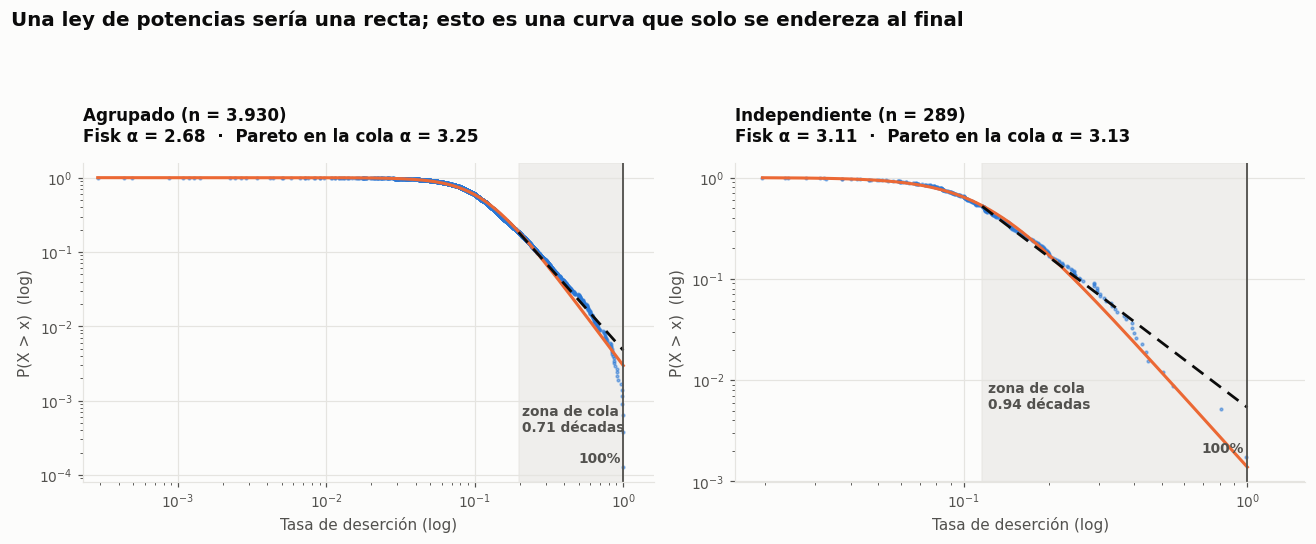

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nom, v, cc, ss) in zip(axes, [
        ("Agrupado (n = 3.930)", x, c_pool, s_pool),
        ("Independiente (n = 289)", med_ies, c_ies, s_ies)]):
    vs = np.sort(v)
    sf = 1 - (np.arange(1, len(vs) + 1) - .5) / len(vs)
    ax.loglog(vs, sf, ".", color=AZUL, markersize=3.5, alpha=.5)

    rej = np.logspace(np.log10(vs.min()), 0, 300)
    ax.loglog(rej, stats.fisk.sf(rej, cc, 0, ss), color=NARANJA, linewidth=2)

    xm, al, ks, nt = pl_mejor(v)
    cola = np.logspace(np.log10(xm), 0, 60)
    sf_xm = (sf[np.searchsorted(vs, xm)] if xm <= vs[-1] else sf[-1])
    ax.loglog(cola, sf_xm * (cola / xm) ** (1 - al), color=TINTA,
              linewidth=1.8, linestyle=(0, (5, 3)))
    ax.axvspan(xm, 1.0, color=REJILLA, alpha=.55, zorder=0)
    ax.axvline(1.0, color=TINTA_2, linewidth=1.2)

    ax.annotate(f"zona de cola\n{np.log10(1/xm):.2f} décadas",
                xy=(xm * 1.05, sf.min() * 3), color=TINTA_2, fontsize=9,
                fontweight="bold")
    ax.annotate("100%", xy=(0.97, sf.min() * 1.05), ha="right", va="bottom",
                color=TINTA_2, fontsize=9, fontweight="bold")
    ax.set_title(f"{nom}\nFisk α = {cc:.2f}  ·  Pareto en la cola α = {al:.2f}",
                 fontsize=11)
    ax.set_xlabel("Tasa de deserción (log)")
    ax.set_ylabel("P(X > x)  (log)")
    ax.set_xlim(vs.min() * .8, 1.6)
    limpiar(ax)

fig.suptitle("Una ley de potencias sería una recta; esto es una curva que solo se "
             "endereza al final",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=TINTA)
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

*Puntos azules: supervivencia empírica. Naranja: log-logística ajustada. Negro
punteado: Pareto ajustada sobre la cola. Banda gris: zona de cola (x ≥ xmin).
Línea vertical: el 100%, techo estructural de una proporción.*

En log-log, **una ley de potencias es una línea recta en todo su recorrido**.
Lo que se ve es una meseta plana que se curva y solo se aproxima a la recta (línea
negra punteada) dentro del tramo sombreado, antes de chocar con el techo del 100%.
La curva naranja es la Fisk ajustada: reproduce **tanto la meseta del cuerpo como
el enderezamiento final**, y por eso le gana a la Pareto sobre el rango completo.

El panel derecho muestra además el límite del argumento: en el extremo, los puntos
observados quedan por debajo de la recta de Pareto: la cola real decae **más
rápido** de lo que una ley de potencias predice, justamente porque existe el tope
del 100%.

---
## 22. Veredicto

**No se puede afirmar que la deserción estudiantil siga una ley de potencias.**

Lo que sí se puede afirmar, con precisión:

> *"La distribución de tasas de deserción por IES se ajusta a una log-logística de
> forma c ≈ 3,1, cuya cola superior decae asintóticamente como una potencia de
> exponente α ≈ 3,1 — estimación que un ajuste directo de Pareto sobre la cola
> (Clauset et al.) reproduce de forma independiente (α̂ = 3,13). Esto implica una
> cola más pesada que la lognormal, pero el fenómeno no es libre de escala: tiene
> una moda interior en torno al 9% y está acotado en 100%."*

Y lo que **no** se puede afirmar, con el motivo:

| Afirmación tentadora | Por qué no |
|---|---|
| "La deserción sigue una ley de potencias" | La Pareto pura sobre el rango completo queda **penúltima de 13 familias** (ΔAIC = 181). El cuerpo de la distribución tiene una moda interior en ≈ 9%; una ley de potencias es monótona decreciente y no tiene moda. |
| "La cola es una ley de potencias (lo probé con Clauset)" | Con los datos agrupados **se rechaza** (p = 0,040). Con los independientes no se rechaza, pero α̂ = 3,125 reproduce la forma de la Fisk (c = 3,111): el test **confirma el modelo ya ajustado**, no descubre una ley nueva. |
| "Hay invariancia de escala / fenómeno libre de escala" | La cola cubre **0,70–0,93 décadas**; el criterio usual pide ≥ 2. Es una limitación **estructural**: una proporción acotada en [0,1] con moda en 10% no puede ofrecer más de una década. Y el fenómeno tiene escala característica evidente (mediana 11%). |
| "La Pareto le gana a la log-logística en la cola (LR, p = 0,018)" | Sobre `xmin` ambas curvas casi coinciden — la Fisk *es* Pareto ahí. La Pareto gana por usar un parámetro en vez de dos en esa región, no por describirla mejor. Sobre el rango completo pierde por ΔAIC = 181. |
| "α ≈ 3 indica criticidad / colas infinitas" | En el extremo los datos caen **por debajo** de la recta de Pareto (sección 21): la cola real decae más rápido, por el tope del 100%. La varianza empírica es finita y está en la Parte I. |

**En términos prácticos para el estudio:** la log-logística es una buena elección
*descriptiva* — ajusta, no se rechaza, y su parámetro de forma resume la dispersión
en un número. Pero no autoriza el vocabulario de las leyes de potencias
(invariancia de escala, criticidad, "libre de escala", mecanismos de apego
preferencial). Presentarla así sería sobreinterpretar el modelo: la cola pesada es
una **propiedad de la familia ajustada**, verificada dentro de menos de una década
de recorrido, no un hecho establecido sobre el fenómeno.

Si el interés real es el mecanismo detrás de la cola —por qué existen IES con
deserción del 40% o más— el camino no es un test de ley de potencias sobre 0,9
décadas, sino modelar esa cola con covariables: tamaño de cohorte, tipo de
institución, región, nivel de formación. La Parte I ya sugiere por dónde: los
extremos se concentran en instituciones de cohorte pequeña.

---
# Parte IV — La estructura que sí está en los datos

La ley de potencias no describe este fenómeno, y la Parte III explicó por qué.
Pero el análisis dejó un hallazgo colateral mucho más sólido: **el ICC de 0,553**.
Más de la mitad de la variación no está en el tiempo ni en el azar, sino *entre
instituciones*.

Eso es una relación, y se puede modelar. Esta parte pone a competir tres
candidatos sobre los mismos datos:

| Modelo | Qué afirma |
|---|---|
| **Cadena de Markov (orden 1)** | El estado del año que viene depende solo del estado de este año |
| **AR(1)** | La versión continua de lo mismo: `y(t) = ρ·y(t−1) + ruido` |
| **Componentes de varianza** | Cada IES tiene un nivel permanente, más ruido transitorio |

Los tres predicen cosas distintas y medibles. Se deja que los datos elijan.

## 23. La prueba que separa los tres modelos

Markov de orden 1 y AR(1) implican que la memoria **decae geométricamente**: si la
correlación a un año es r, a dos años debe ser r², a tres r³. Un efecto permanente
implica que la correlación **no decae**: se queda plana.

Basta medir la autocorrelación a distintos rezagos dentro de cada institución.
Antes se le quita a cada año su media, para que la tendencia común 2010–2024 no
se confunda con persistencia institucional.

In [30]:
dat["l_sin_anio"] = dat["log_tasa"] - dat.groupby("anio")["log_tasa"].transform("mean")
tabla_ies = dat.pivot_table(index="CODIGO IES PADRE", columns="anio", values="l_sin_anio")

acf = {}
for h in range(1, 8):
    a, b = [], []
    for col in tabla_ies.columns:
        if col + h in tabla_ies.columns:
            u, v = tabla_ies[col], tabla_ies[col + h]
            m = u.notna() & v.notna()
            a.extend(u[m]); b.extend(v[m])
    acf[h] = np.corrcoef(a, b)[0, 1]

r1 = acf[1]
comp = pd.DataFrame({
    "observado": pd.Series(acf),
    "Markov / AR(1)": pd.Series({h: r1 ** h for h in acf}),
    "efecto permanente": pd.Series({h: r1 for h in acf}),
})
comp.index.name = "rezago (años)"
comp.round(4)

,observado,Markov / AR(1),efecto permanente
rezago (años),,,
1,0.6992,0.6992,0.6992
2,0.6583,0.4889,0.6992
3,0.6255,0.3419,0.6992
4,0.6133,0.2390,0.6992
5,0.5343,0.1671,0.6992
6,0.5064,0.1169,0.6992
7,0.5233,0.0817,0.6992


**La memoria no decae como debería.** A cinco años la correlación observada es
**0,534**; Markov y AR(1) predicen **0,167**. El modelo geométrico se queda corto
por un factor de tres. Pero tampoco es un efecto puramente permanente: la
correlación sí baja algo entre el rezago 1 y el 5.

La forma correcta es la mezcla de ambos: una parte permanente que nunca se va, más
una parte transitoria que se olvida.

$$r(h) = \lambda + (1-\lambda)\,\rho^{h}$$

In [31]:
from scipy import optimize

hs = np.array(sorted(acf)); rs = np.array([acf[h] for h in hs])

def sse_componentes(p):
    lam, rho = p
    return np.sum((lam + (1 - lam) * rho ** hs - rs) ** 2)

opt = optimize.minimize(sse_componentes, [0.5, 0.5], bounds=[(0, .99), (0, .99)])
LAM, RHO = opt.x

sse = lambda pred: float(np.sum((pred - rs) ** 2))
print(f"lambda (parte permanente de la institución) = {LAM:.4f}")
print(f"rho    (persistencia de lo transitorio)     = {RHO:.4f}\n")
print(f"  SSE modelo de componentes (2 parámetros) = {sse(LAM + (1-LAM)*RHO**hs):.5f}")
print(f"  SSE Markov / AR(1)        (1 parámetro)  = {sse(r1**hs):.5f}"
      f"   -> {sse(r1**hs)/sse(LAM+(1-LAM)*RHO**hs):.0f} veces peor")
print(f"  SSE efecto permanente puro               = {sse(np.full_like(rs, r1)):.5f}")

lambda (parte permanente de la institución) = 0.5397
rho    (persistencia de lo transitorio)     = 0.4650

  SSE modelo de componentes (2 parámetros) = 0.00963
  SSE Markov / AR(1)        (1 parámetro)  = 0.73079   -> 76 veces peor
  SSE efecto permanente puro               = 0.10981


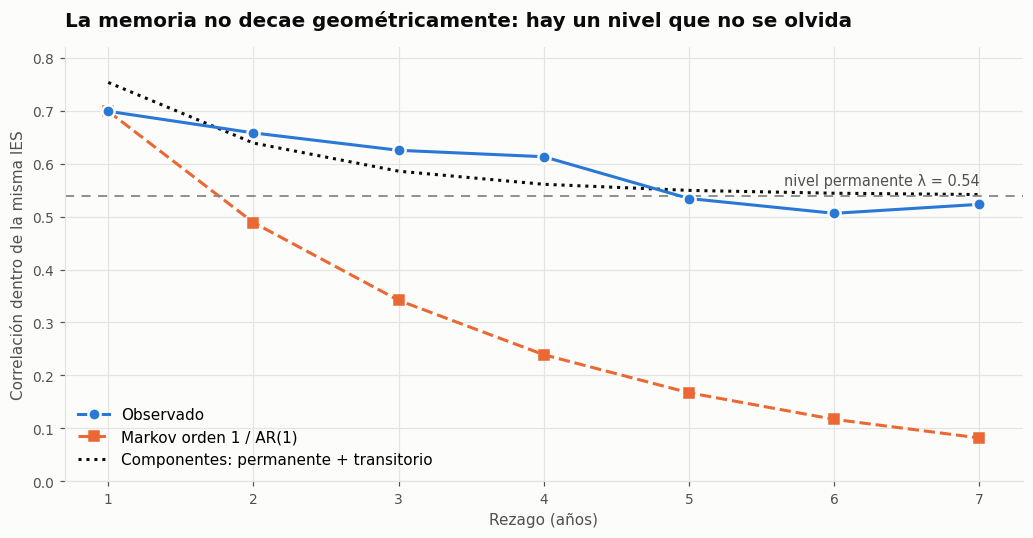

In [32]:
fig, ax = plt.subplots(figsize=(9.5, 5))

ax.plot(hs, rs, "o-", color=AZUL, linewidth=2, markersize=8,
        markeredgecolor=SUPERF, markeredgewidth=1.6, label="Observado", zorder=5)
ax.plot(hs, r1 ** hs, "s--", color=NARANJA, linewidth=2, markersize=6,
        label="Markov orden 1 / AR(1)")
ax.plot(hs, LAM + (1 - LAM) * RHO ** hs, color=TINTA, linewidth=2,
        linestyle=(0, (1, 1.6)), label="Componentes: permanente + transitorio")
ax.axhline(LAM, color=GRIS, linewidth=1.2, linestyle=(0, (5, 4)))
ax.annotate(f"nivel permanente λ = {LAM:.2f}", xy=(7, LAM), xytext=(0, 7),
            textcoords="offset points", ha="right", color=TINTA_2, fontsize=9.5)

ax.set_title("La memoria no decae geométricamente: hay un nivel que no se olvida")
ax.set_xlabel("Rezago (años)")
ax.set_ylabel("Correlación dentro de la misma IES")
ax.set_ylim(0, .82)
ax.set_xticks(hs)
ax.legend(frameon=False, fontsize=10, loc="lower left")
limpiar(ax)
plt.tight_layout()
plt.show()

Este gráfico resuelve la pregunta por sí solo. La curva naranja es lo que
**tendría** que verse si el proceso fuera markoviano; los puntos azules son lo que
**se ve**. Markov no se queda corto por poco: a partir del segundo año está fuera
de rango, y su error cuadrático es **76 veces mayor** que el del modelo de
componentes.

## 24. Aun así, conviene estimar la cadena de Markov

Porque la matriz de transición es informativa por sí misma, y porque el rechazo
debe ser formal, no gráfico. Se discretiza cada institución-año en **quintiles
calculados dentro de su año**, de modo que el estado mide posición relativa y la
tendencia general no contamina las transiciones.

In [33]:
dat["quintil"] = dat.groupby("anio")["tasa"].transform(
    lambda v: pd.qcut(v, 5, labels=False, duplicates="drop"))
panel = dat.dropna(subset=["quintil"]).copy()
panel["quintil"] = panel["quintil"].astype(int)

transiciones = []
tripletas = []
for ies, g in panel.groupby("CODIGO IES PADRE"):
    g = g.sort_values("anio")
    an, es = g["anio"].to_numpy(), g["quintil"].to_numpy()
    for k in range(len(g) - 1):
        if an[k + 1] == an[k] + 1:
            transiciones.append((ies, an[k], es[k], es[k + 1]))
    for k in range(len(g) - 2):
        if an[k + 1] == an[k] + 1 and an[k + 2] == an[k] + 2:
            tripletas.append((es[k], es[k + 1], es[k + 2]))

TR = pd.DataFrame(transiciones, columns=["ies", "anio", "i", "j"])
TRI = pd.DataFrame(tripletas, columns=["h", "i", "j"])
S = 5
ETQ = ["Q1 (más baja)", "Q2", "Q3", "Q4", "Q5 (más alta)"]

N = np.zeros((S, S))
for i, j in zip(TR.i, TR.j):
    N[i, j] += 1
P = N / N.sum(axis=1, keepdims=True)

print(f"transiciones año a año: {len(TR):,}   tripletas: {len(TRI):,}\n")
pd.DataFrame(P, index=ETQ, columns=[f"→ Q{k+1}" for k in range(S)]).round(3)

transiciones año a año: 3,605   tripletas: 3,296



,→ Q1,→ Q2,→ Q3,→ Q4,→ Q5
Q1 (más baja),0.729,0.173,0.041,0.036,0.021
Q2,0.177,0.515,0.221,0.069,0.018
Q3,0.050,0.208,0.468,0.230,0.044
Q4,0.032,0.080,0.221,0.475,0.193
Q5 (más alta),0.022,0.029,0.055,0.195,0.700


In [34]:
print(f"persistencia (diagonal) : {np.round(np.diag(P), 3)}")
print(f"traza                   : {np.trace(P):.3f}   (5 = nadie se mueve, 1 = todo azar)")
print(f"índice de movilidad     : {(S - np.trace(P)) / (S - 1):.3f}")
print(f"permanencia esperada en Q5 : {1/(1-P[4,4]):.2f} años")
print(f"permanencia esperada en Q1 : {1/(1-P[0,0]):.2f} años")

vals, vecs = np.linalg.eig(P.T)
k = np.argmin(np.abs(vals - 1))
pi = np.real(vecs[:, k]); pi /= pi.sum()
slem = np.sort(np.abs(vals))[::-1][1]
print(f"\ndistribución estacionaria  : {np.round(pi, 3)}")
print(f"segundo autovalor |λ₂|     : {slem:.4f}")
print(f"vida media de convergencia : {np.log(0.5)/np.log(slem):.1f} años")

persistencia (diagonal) : [0.729 0.515 0.468 0.475 0.7  ]
traza                   : 2.887   (5 = nadie se mueve, 1 = todo azar)
índice de movilidad     : 0.528
permanencia esperada en Q5 : 3.33 años
permanencia esperada en Q1 : 3.70 años

distribución estacionaria  : [0.21  0.205 0.203 0.198 0.184]
segundo autovalor |λ₂|     : 0.7647
vida media de convergencia : 2.6 años


**La matriz es en forma de U:** los extremos retienen (Q1 el 73%, Q5 el 70%),
el centro no (Q3 el 47%). Una institución de deserción muy alta o muy baja tiende a
quedarse donde está; las del medio circulan. Eso ya sugiere que lo que persiste es
un atributo de la institución, no una inercia del estado.

### Las tres pruebas formales sobre la cadena

In [35]:
def g2(tabla):
    """Razón de verosimilitud G² contra independencia entre filas y columnas."""
    fil, col, tot = tabla.sum(1), tabla.sum(0), tabla.sum()
    esp = np.outer(fil, col) / tot
    est = 2 * np.nansum(np.where(tabla > 0, tabla * np.log(tabla / esp), 0))
    gl = ((fil > 0).sum() - 1) * ((col > 0).sum() - 1)
    return est, gl

# 1) ¿Hay dependencia? orden 1 contra orden 0
e0, gl0 = g2(N)
print(f"1. Orden 1 vs orden 0  (H0: los años son independientes)")
print(f"   G² = {e0:,.1f}   gl = {gl0}   p = {stats.chi2.sf(e0, gl0):.3g}"
      f"   -> {'RECHAZA' if stats.chi2.sf(e0,gl0)<.05 else 'no rechaza'}\n")

# 2) ¿Basta un rezago? orden 2 contra orden 1
e1 = gl1 = 0
for i in range(S):
    sub = TRI[TRI.i == i]
    if len(sub) < 30:
        continue
    M = np.zeros((S, S))
    for h, j in zip(sub.h, sub.j):
        M[h, j] += 1
    a, b = g2(M)
    e1 += a; gl1 += b
print(f"2. Orden 2 vs orden 1  (H0: se cumple la propiedad de Markov)")
print(f"   G² = {e1:,.1f}   gl = {gl1}   p = {stats.chi2.sf(e1, gl1):.3g}"
      f"   -> {'RECHAZA' if stats.chi2.sf(e1,gl1)<.05 else 'no rechaza'}\n")

# 3) ¿La matriz es la misma todos los años?
e2 = gl2 = 0
for i in range(S):
    filas = [np.array([((TR.i == i) & (TR.anio == a) & (TR.j == j)).sum()
                       for j in range(S)])
             for a in sorted(TR.anio.unique())
             if ((TR.i == i) & (TR.anio == a)).sum() >= 20]
    if len(filas) > 1:
        a_, b_ = g2(np.array(filas, dtype=float))
        e2 += a_; gl2 += b_
print(f"3. Homogeneidad temporal  (H0: la matriz no cambia entre años)")
print(f"   G² = {e2:,.1f}   gl = {gl2}   p = {stats.chi2.sf(e2, gl2):.3g}"
      f"   -> {'RECHAZA' if stats.chi2.sf(e2,gl2)<.05 else 'no rechaza'}")

1. Orden 1 vs orden 0  (H0: los años son independientes)
   G² = 3,462.2   gl = 16   p = 0   -> RECHAZA

2. Orden 2 vs orden 1  (H0: se cumple la propiedad de Markov)
   G² = 573.8   gl = 80   p = 1.01e-75   -> RECHAZA

3. Homogeneidad temporal  (H0: la matriz no cambia entre años)
   G² = 242.3   gl = 260   p = 0.778   -> no rechaza


Las tres pruebas dicen algo distinto y las tres importan:

1. **Hay dependencia, y es enorme** (p ≈ 0). Los años de una misma IES no son
   independientes. Cualquier análisis que los trate como 3.930 datos sueltos está
   mal — como ya había advertido la Parte II.
2. **La propiedad de Markov se rechaza** (p ≈ 1e-75). Sabiendo dónde estuvo una
   institución hace dos años se predice mejor que sabiendo solo dónde está hoy.
   Eso es exactamente lo que hace un efecto permanente y lo que una cadena de
   orden 1 no puede representar.
3. **La matriz sí es estable en el tiempo** (p = 0,78). Es el único de los tres
   supuestos que sobrevive, y es un resultado útil: el patrón de movilidad de 2011
   sirve para 2023.

## 25. Dónde falla Markov en la práctica

Una prueba de hipótesis no dice *cuánto* importa el error. Esto sí: se toman las
IES que estaban en el quintil más alto y se compara dónde predice la cadena que
estarán cinco años después, contra dónde están de verdad.

In [36]:
P5 = np.linalg.matrix_power(P, 5)

obs5 = []
for ies, g in panel.groupby("CODIGO IES PADRE"):
    g = g.sort_values("anio")
    an, es = g["anio"].to_numpy(), g["quintil"].to_numpy()
    for k in range(len(g) - 5):
        if an[k + 5] == an[k] + 5 and es[k] == 4:
            obs5.append(es[k + 5])
obs5 = np.array(obs5)
emp5 = np.array([(obs5 == j).mean() for j in range(S)])

cmp5 = pd.DataFrame({"Markov a 5 pasos": P5[4], "Observado": emp5},
                    index=[f"Q{k+1}" for k in range(S)])
g5 = 2 * np.nansum(np.where(emp5 > 0, len(obs5) * emp5 * np.log(emp5 / P5[4]), 0))
print(f"IES seguidas 5 años desde Q5: {len(obs5)}")
print(f"G² = {g5:.1f}   gl = {S-1}   p = {stats.chi2.sf(g5, S-1):.3g}\n")
cmp5.round(3)

IES seguidas 5 años desde Q5: 435
G² = 166.3   gl = 4   p = 6.64e-35



,Markov a 5 pasos,Observado
Q1,0.115,0.025
Q2,0.148,0.048
Q3,0.188,0.120
Q4,0.239,0.251
Q5,0.309,0.556


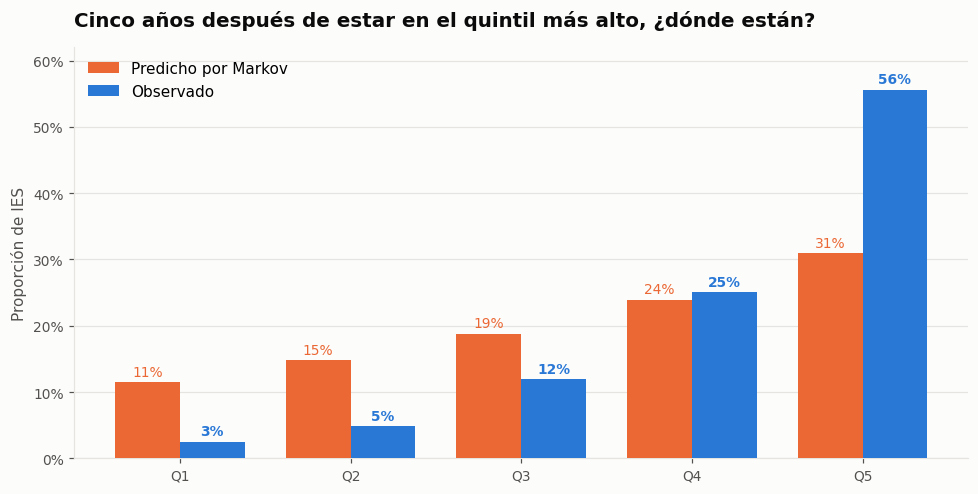

In [37]:
fig, ax = plt.subplots(figsize=(9, 4.6))
pos = np.arange(S); an_ = 0.38

ax.bar(pos - an_/2, P5[4], an_, label="Predicho por Markov", color=NARANJA, zorder=3)
ax.bar(pos + an_/2, emp5, an_, label="Observado", color=AZUL, zorder=3)
for k in range(S):
    ax.annotate(f"{emp5[k]:.0%}", xy=(k + an_/2, emp5[k]), xytext=(0, 4),
                textcoords="offset points", ha="center", color=AZUL,
                fontsize=9, fontweight="bold")
    ax.annotate(f"{P5[4][k]:.0%}", xy=(k - an_/2, P5[4][k]), xytext=(0, 4),
                textcoords="offset points", ha="center", color=NARANJA, fontsize=9)

ax.set_title("Cinco años después de estar en el quintil más alto, ¿dónde están?")
ax.set_xticks(pos)
ax.set_xticklabels([f"Q{k+1}" for k in range(S)])
ax.set_ylabel("Proporción de IES")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, .62)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, fontsize=10)
limpiar(ax)
plt.tight_layout()
plt.show()

**Markov predice que el 31% seguirá en el quintil alto; de verdad sigue el
56%.** Casi el doble. Y en el otro extremo predice que un 11,5% habrá caído hasta
el quintil más bajo, cuando en realidad solo lo hace el 2,5%.

El error tiene una dirección clara: **la cadena olvida quién es la institución.**
Cada año la trata como si su historia empezara de cero, y por eso la devuelve
hacia el promedio mucho más rápido de lo que ocurre. Las universidades con
deserción estructuralmente alta no regresan a la media: se quedan.

## 26. El modelo que sí ajusta

$$\log(\text{tasa})_{it} = \mu_t + \alpha_i + \varepsilon_{it}$$

- $\mu_t$ — el año, común a todas (la tendencia 2010–2024).
- $\alpha_i$ — el nivel propio y permanente de cada institución.
- $\varepsilon_{it}$ — lo transitorio, con persistencia ρ.

Cuánto pesa cada pieza:

Año (choque común)                  3.1%
Institución (nivel permanente)     58.5%
Residuo (idiosincrásico)           38.6%


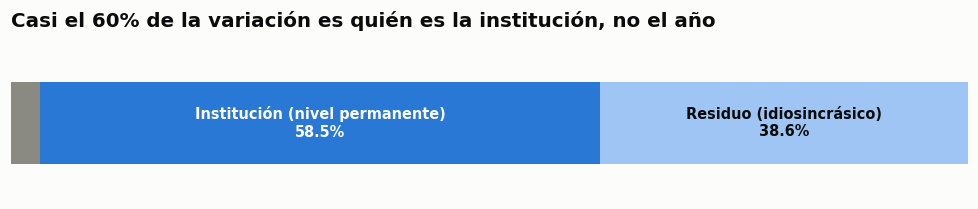

In [38]:
total = dat["log_tasa"].var(ddof=1)
v_anio = dat.groupby("anio")["log_tasa"].transform("mean").var(ddof=1)
v_ies = dat.groupby("CODIGO IES PADRE")["log_tasa"].transform("mean").var(ddof=1)
residuo = (dat["log_tasa"]
           - dat.groupby("CODIGO IES PADRE")["log_tasa"].transform("mean")
           - dat.groupby("anio")["log_tasa"].transform("mean")
           + dat["log_tasa"].mean())

partes = pd.Series({
    "Año (choque común)": v_anio / total,
    "Institución (nivel permanente)": v_ies / total,
    "Residuo (idiosincrásico)": residuo.var(ddof=1) / total,
})
print(partes.map(lambda v: f"{v:6.1%}").to_string())

fig, ax = plt.subplots(figsize=(9, 2.0))
izq = 0
colores = [GRIS, AZUL, AZUL_CL]
for (nombre, v), col in zip(partes.items(), colores):
    ax.barh(0, v, left=izq, color=col, height=.55)
    if v > .06:
        ax.annotate(f"{nombre}\n{v:.1%}", xy=(izq + v/2, 0), ha="center", va="center",
                    color=SUPERF if col == AZUL else TINTA, fontsize=9.5,
                    fontweight="bold")
    izq += v
ax.set_xlim(0, 1); ax.set_ylim(-.5, .5)
ax.set_yticks([]); ax.set_xticks([])
ax.set_title("Casi el 60% de la variación es quién es la institución, no el año")
for s in ("top", "right", "left", "bottom"):
    ax.spines[s].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

**El año explica el 3,1%. La institución, el 58,5%.**

Es el resultado más accionable de todo el cuaderno: la deserción de una
universidad colombiana es, ante todo, un atributo de esa universidad. Las
políticas dirigidas al sistema entero mueven el 3% de la variación; el otro 58%
está en las instituciones concretas.

## 27. Patrones

Con el modelo identificado, se pueden buscar regularidades concretas.

In [39]:
# --- Patrón 1: ¿cuánto se mueven las instituciones? ---
g = panel.groupby("CODIGO IES PADRE")["quintil"]
movilidad = pd.DataFrame({
    "anios": g.size(),
    "distintos": g.nunique(),
    "modo": g.agg(lambda s: s.mode().iloc[0]),
    "frac_modo": g.agg(lambda s: (s == s.mode().iloc[0]).mean()),
})
est = movilidad[movilidad.anios >= 10]

print(f"IES con 10 años o más: {len(est)}\n")
print("Quintiles distintos visitados en toda su historia:")
for k, v in est.distintos.value_counts().sort_index().items():
    print(f"   {k} de 5 : {v:3d} IES  {'█' * int(v/2)}")
print(f"\nPasan el 70% o más de sus años en un mismo quintil: {(est.frac_modo >= .7).mean():.1%}")
print("\nAdherencia al quintil habitual, según cuál sea:")
for q in range(5):
    sub = est[est.modo == q]
    print(f"   Q{q+1}: {len(sub):3d} IES   permanece el {sub.frac_modo.mean():.0%} de sus años")

IES con 10 años o más: 258

Quintiles distintos visitados en toda su historia:
   1 de 5 :  17 IES  ████████
   2 de 5 :  53 IES  ██████████████████████████
   3 de 5 :  92 IES  ██████████████████████████████████████████████
   4 de 5 :  78 IES  ███████████████████████████████████████
   5 de 5 :  18 IES  █████████

Pasan el 70% o más de sus años en un mismo quintil: 32.6%

Adherencia al quintil habitual, según cuál sea:
   Q1:  60 IES   permanece el 68% de sus años
   Q2:  45 IES   permanece el 61% de sus años
   Q3:  51 IES   permanece el 53% de sus años
   Q4:  51 IES   permanece el 54% de sus años
   Q5:  51 IES   permanece el 71% de sus años


**Los extremos son pegajosos; el medio circula.** Una institución cuyo lugar
habitual es Q5 pasa allí el 71% de sus años, y una de Q1 el 68%. En Q3 la
adherencia cae al 53% — casi un lanzamiento de moneda. Diecisiete instituciones
no salieron nunca de su quintil en 15 años.

In [40]:
# --- Patrón 2: forma de la trayectoria ---
filas = []
for ies, g2_ in dat.groupby("CODIGO IES PADRE"):
    g2_ = g2_.sort_values("anio")
    if len(g2_) < 12:
        continue
    y, xx = g2_["log_tasa"].to_numpy(), g2_["anio"].to_numpy()
    pend, inter, rr, pv, _ = stats.linregress(xx, y)
    filas.append({"nivel": np.exp(y.mean()), "pend": pend, "p": pv,
                  "volat": (y - (inter + pend * xx)).std(ddof=1)})
formas = pd.DataFrame(filas)
med_vol = formas.volat.median()
formas["patron"] = [
    ("baja" if (r.pend < 0 and r.p < .05) else "sube" if (r.pend > 0 and r.p < .05) else "plana")
    + " · " + ("volátil" if r.volat > med_vol else "estable")
    for r in formas.itertuples()]

print(f"IES con 12 años o más: {len(formas)}\n")
print(formas.patron.value_counts().to_string())
print(f"\ncambio anual mediano      : {(np.exp(formas.pend.median())-1)*100:+.2f}%")
print(f"bajan significativamente  : {((formas.pend<0)&(formas.p<.05)).sum()}")
print(f"suben significativamente  : {((formas.pend>0)&(formas.p<.05)).sum()}")
rr, pp = stats.pearsonr(np.log(formas.nivel), formas.volat)
print(f"\ncorr(nivel, volatilidad)  : {rr:+.3f}   p = {pp:.3g}")

IES con 12 años o más: 245

patron
baja · estable     80
plana · volátil    70
baja · volátil     47
plana · estable    38
sube · estable      5
sube · volátil      5

cambio anual mediano      : -2.84%
bajan significativamente  : 127
suben significativamente  : 10

corr(nivel, volatilidad)  : -0.168   p = 0.00823


Dos patrones que vale la pena separar:

- **El descenso es mayoritario pero no universal.** 127 de 245 instituciones bajan
  con significancia estadística; solo 10 suben. La mediana cae 2,84% anual.
- **Las de deserción alta no son las más erráticas, sino las menos.** La
  correlación entre nivel y volatilidad es **−0,168** (p = 0,008). Es
  contraintuitivo y refuerza todo lo anterior: una deserción alta y sostenida es
  un rasgo estable de la institución, no una racha de mala suerte.

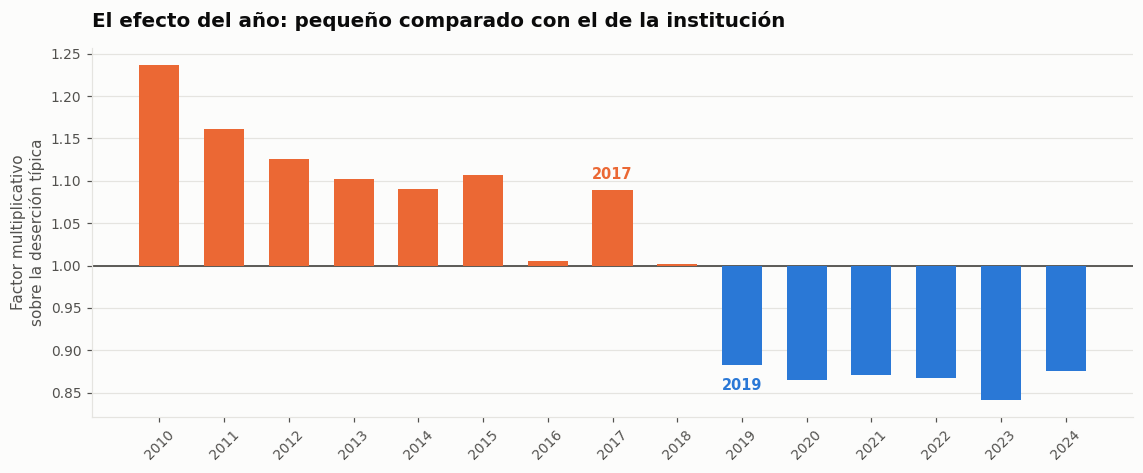

salto a la baja mayor: 2019 (-11.9%)
salto al alza mayor  : 2017 (+8.4%)

RIC 2020: 0.070   RIC 2021: 0.098   (+40%)


In [41]:
# --- Patrón 3: el choque común año a año ---
media_anio = dat.groupby("anio")["log_tasa"].mean()
factor = np.exp(media_anio - media_anio.mean())
ric_anio = (dat.groupby("anio")["tasa"].quantile(.75)
            - dat.groupby("anio")["tasa"].quantile(.25))

fig, ax = plt.subplots(figsize=(10.5, 4.4))
colores = [NARANJA if v > 1 else AZUL for v in factor]
ax.bar(factor.index, factor - 1, bottom=1, color=colores, width=.62, zorder=3)
ax.axhline(1, color=TINTA_2, linewidth=1.2)
for a_, v in factor.items():
    if a_ in (2017, 2019):
        ax.annotate(f"{a_}", xy=(a_, v), xytext=(0, 7 if v > 1 else -16),
                    textcoords="offset points", ha="center",
                    color=NARANJA if v > 1 else AZUL, fontsize=9.5, fontweight="bold")

ax.set_title("El efecto del año: pequeño comparado con el de la institución")
ax.set_ylabel("Factor multiplicativo\nsobre la deserción típica")
ax.set_xticks(factor.index)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="x", visible=False)
limpiar(ax)
plt.tight_layout()
plt.show()

print(f"salto a la baja mayor: {media_anio.diff().idxmin()} "
      f"({(np.exp(media_anio.diff().min())-1)*100:+.1f}%)")
print(f"salto al alza mayor  : {media_anio.diff().idxmax()} "
      f"({(np.exp(media_anio.diff().max())-1)*100:+.1f}%)")
print(f"\nRIC 2020: {ric_anio[2020]:.3f}   RIC 2021: {ric_anio[2021]:.3f}"
      f"   ({(ric_anio[2021]/ric_anio[2020]-1)*100:+.0f}%)")

El choque común existe pero es modesto: entre 2010 y 2024 el factor va de
1,24 a 0,88, y el mayor movimiento de un año a otro fue **−11,9% en 2019**. El
repunte de **+8,4% en 2017** es la única subida notable.

Un detalle que la Parte I había dejado señalado: **en 2021 el rango
intercuartílico sube un 40% respecto a 2020**. La pandemia no movió tanto el nivel
típico como la *dispersión*: unas instituciones aguantaron y otras no. Es
exactamente el tipo de episodio que un modelo de efecto permanente puro no captura
y que el término transitorio sí.

---
## 28. Conclusión de la Parte IV

**No es una ley de potencias, y tampoco es una cadena de Markov.** Es un proceso
de componentes: nivel institucional permanente más ruido transitorio persistente.

| Modelo | Veredicto | Evidencia |
|---|---|---|
| Ley de potencias | **No** | Pareto pura penúltima de 13; cola de 0,9 décadas (Parte III) |
| Markov orden 1 | **Rechazado** | Orden 2 vs 1: p ≈ 1e-75. A 5 años predice 31% de permanencia; es 56% |
| AR(1) | **Rechazado** | La autocorrelación no decae geométricamente: r(5) = 0,53, no 0,17 |
| **Componentes de varianza** | **Se sostiene** | λ = 0,54 permanente + ρ = 0,47 transitorio; SSE 76× menor |

Lo que sí sobrevive de la cadena de Markov es su **matriz de transición**, que
resultó **estable en el tiempo** (p = 0,78) y con forma de U: los extremos retienen
(Q1 73%, Q5 70%), el centro circula (Q3 47%). Sirve como descripción de la
movilidad, no como mecanismo generador.

### La relación, en una frase

> La deserción de una institución colombiana se predice mucho mejor por **cuál
> institución es** que por **cuándo se la mide** o por **dónde estaba el año
> pasado**. El 58,5% de la variación es la institución; el año aporta el 3,1%.

### Cómo se conectan las cuatro partes

La distribución de la Parte II (log-logística) describe el **corte transversal** de
un año. La estructura de esta parte describe **cómo se encadenan** esos cortes. Las
dos juntas son el modelo completo, y son justamente las dos piezas del simulador:
la marginal log-logística de cada año, más una cópula que reparte la varianza entre
el efecto institución y el ruido transitorio.

### Qué queda pendiente

El modelo dice *cuánta* variación es institucional, no *por qué*. El siguiente paso
natural es explicar α_i con covariables: tamaño de cohorte, carácter público o
privado, región, nivel de formación, área de conocimiento. Ahí es donde el hallazgo
se vuelve accionable.

---
# Parte V — Auditoría crítica

Las cuatro partes anteriores llegaron a conclusiones. Esta parte las ataca.

No es una sección de cortesía: dos de los hallazgos anteriores **no sobreviven**
y quedan corregidos aquí. Se revisan ocho puntos, del más grave al más menor.

## 29. Fallo grave 1 — El diseño de la inferencia estaba mal planteado

La Parte II argumentó que las 3.930 filas no son independientes (ICC = 0,553) y
resolvió el problema **resumiendo cada IES por la mediana de sus 15 años**. El
diagnóstico era correcto; el remedio, no.

La mediana de 15 años de una institución **no es una observación de la
distribución transversal**. Mezcla años con escalas distintas —la escala cayó
2,75% anual— y promedia el componente transitorio. Es una cantidad legítima, pero
responde a otra pregunta: *¿cómo se distribuye el nivel típico de una
institución?*, no *¿cómo se distribuyen las tasas en un año?*

Y había una solución mejor a la vista: **dentro de un año no hay medidas
repetidas.** Cada institución aparece exactamente una vez. Un corte transversal
anual ya es una muestra independiente, con n ≈ 265, sin promediar nada.

In [42]:
med_ies_v = dat.groupby("CODIGO IES PADRE")["tasa"].median()
anio_ref = dat[dat["anio"] == 2024]["tasa"]

c_med, _, s_med = stats.fisk.fit(med_ies_v[(med_ies_v > 0) & (med_ies_v < 1)], floc=0)
c_ref, _, s_ref = stats.fisk.fit(anio_ref, floc=0)

print("Las dos muestras NO describen la misma distribución:\n")
print(f"  medianas por IES : n = {len(med_ies_v)}   sd = {med_ies_v.std(ddof=1):.4f}"
      f"   forma Fisk = {c_med:.3f}")
print(f"  corte de 2024    : n = {len(anio_ref)}   sd = {anio_ref.std(ddof=1):.4f}"
      f"   forma Fisk = {c_ref:.3f}")
print(f"\n  razón de varianzas = {med_ies_v.var(ddof=1)/anio_ref.var(ddof=1):.3f}")
print("  La forma difiere en 0,29: son poblaciones distintas, no ruido de muestreo.")

Las dos muestras NO describen la misma distribución:

  medianas por IES : n = 289   sd = 0.1071   forma Fisk = 3.111
  corte de 2024    : n = 267   sd = 0.0997   forma Fisk = 2.820

  razón de varianzas = 1.155
  La forma difiere en 0,29: son poblaciones distintas, no ruido de muestreo.


## 30. La consecuencia: el ranking se invierte

Se repite la prueba de bondad de ajuste **año por año**, sobre muestras que son
independientes por construcción, con p-valores por Monte Carlo.

In [43]:
FAMILIAS_AUD = [
    ("Log-Laplace", stats.loglaplace, {"loc": 0}),
    ("Burr XII", stats.burr12, {"loc": 0}),
    ("Log-logística", stats.fisk, {"loc": 0}),
    ("Lognormal", stats.lognorm, {"loc": 0}),
    ("Gamma", stats.gamma, {"loc": 0}),
    ("Weibull", stats.weibull_min, {"loc": 0}),
]

filas_aud = []
for a_, g_ in dat.groupby("anio"):
    v = g_["tasa"].to_numpy()
    fila = {"año": a_, "n": len(v)}
    for nom, dist, known in FAMILIAS_AUD:
        try:
            fila[nom] = stats.goodness_of_fit(
                dist, v, known_params=known, statistic="ad",
                n_mc_samples=299, random_state=11).pvalue
        except Exception:
            fila[nom] = np.nan
    filas_aud.append(fila)

AUD = pd.DataFrame(filas_aud).set_index("año")
print("p-valores de Anderson-Darling por año (0,003 es el mínimo con 299 muestras)\n")
AUD.round(3)

p-valores de Anderson-Darling por año (0,003 es el mínimo con 299 muestras)



,n,Log-Laplace,Burr XII,Log-logística,Lognormal,Gamma,Weibull
año,,,,,,,
2010,251,0.073,0.003,0.023,0.003,0.003,0.003
2011,250,0.073,0.003,0.007,0.003,0.003,0.003
2012,256,0.133,0.403,0.303,0.003,0.003,0.003
2013,254,0.293,0.003,0.030,0.003,0.003,0.003
2014,259,0.007,0.053,0.020,0.003,0.003,0.003
2015,263,0.007,0.357,0.100,0.003,0.003,0.003
2016,268,0.007,0.013,0.020,0.003,0.003,0.003
2017,266,0.160,0.203,0.077,0.003,0.003,0.003
2018,264,0.537,0.013,0.007,0.003,0.003,0.003


In [44]:
resumen_aud = pd.DataFrame({
    "años sin rechazo (de 15)": {n: int((AUD[n] >= .05).sum()) for n, _, _ in FAMILIAS_AUD},
    "p mediano": {n: AUD[n].median() for n, _, _ in FAMILIAS_AUD},
}).sort_values("años sin rechazo (de 15)", ascending=False)
resumen_aud.round(3)

,años sin rechazo (de 15),p mediano
Log-Laplace,12,0.150
Burr XII,7,0.033
Log-logística,5,0.033
Lognormal,0,0.003
Gamma,0,0.003
Weibull,0,0.003


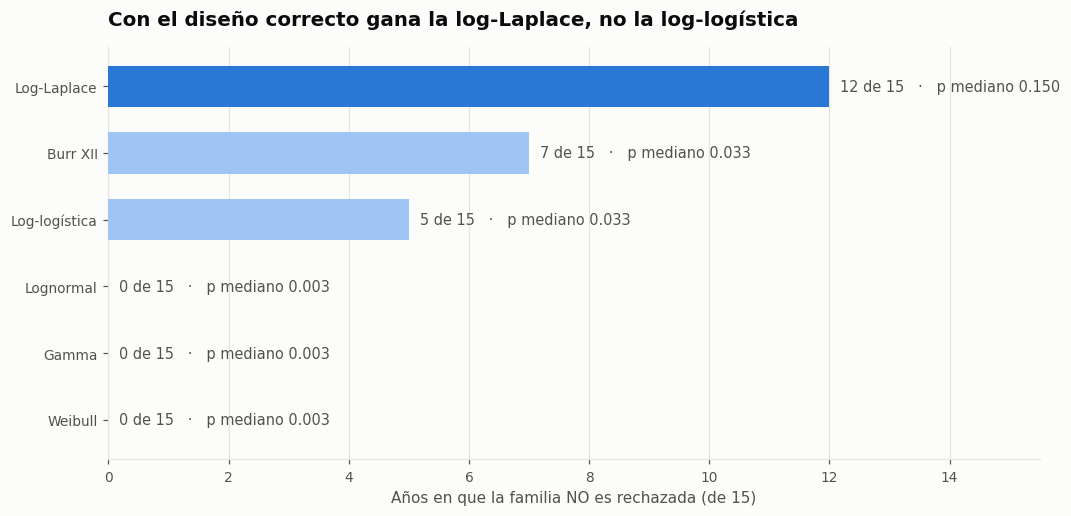

In [45]:
fig, ax = plt.subplots(figsize=(10, 4.8))
nombres = list(resumen_aud.index)
pos = np.arange(len(nombres))
conteo = resumen_aud["años sin rechazo (de 15)"].to_numpy()
colores = [AZUL if v >= 8 else (AZUL_CL if v > 0 else NARANJA) for v in conteo]

ax.barh(pos, conteo, color=colores, height=.62, zorder=3)
for i, v in enumerate(conteo):
    ax.annotate(f"{v} de 15   ·   p mediano {resumen_aud['p mediano'].iloc[i]:.3f}",
                xy=(v, i), xytext=(7, 0), textcoords="offset points",
                va="center", color=TINTA_2, fontsize=9.5)

ax.set_yticks(pos)
ax.set_yticklabels(nombres)
ax.invert_yaxis()
ax.set_xlim(0, 15.5)
ax.set_xlabel("Años en que la familia NO es rechazada (de 15)")
ax.set_title("Con el diseño correcto gana la log-Laplace, no la log-logística")
ax.grid(axis="y", visible=False)
limpiar(ax)
plt.tight_layout()
plt.show()

**La log-Laplace no se rechaza en 12 de los 15 años; la log-logística, solo en
5.** La Parte II había recomendado la log-logística. Con el diseño correcto, esa
recomendación se invierte.

Conviene notar que el resultado **ya estaba insinuado** en la sección 15: al
ajustar año por año, la log-Laplace ganaba por AIC en 9 de 15 años y la
log-logística en 2. Se le restó importancia por anclarse en la muestra de
medianas. Fue un error de juicio, no de cálculo.

Lo que **no** cambia, y se refuerza: la lognormal, la gamma y la Weibull se
rechazan en los 15 años, con el p-valor en el mínimo alcanzable. La conclusión
central de la Parte II —la familia correcta es de tipo log- con colas pesadas—
se mantiene intacta. Lo que cambia es cuál de ellas.

## 31. Fallo grave 2 — Atrición selectiva

El panel es desbalanceado: 289 instituciones, pero solo 267 llegan a 2024.
¿Las que desaparecen se parecen a las que siguen?

In [46]:
ultimo_anio = dat.groupby("CODIGO IES PADRE")["anio"].max()
nivel_ies = dat.groupby("CODIGO IES PADRE")["tasa"].median()
salen = ultimo_anio < dat["anio"].max()

u = stats.mannwhitneyu(nivel_ies[salen], nivel_ies[~salen])
print(f"IES que siguen hasta 2024 : {(~salen).sum()}")
print(f"IES que dejan de aparecer : {salen.sum()}\n")
print(f"  mediana de las que salen  : {nivel_ies[salen].median():.2%}")
print(f"  mediana de las que siguen : {nivel_ies[~salen].median():.2%}")
print(f"  razón                     : {nivel_ies[salen].median()/nivel_ies[~salen].median():.2f}x")
print(f"\n  Mann-Whitney U: p = {u.pvalue:.3g}  -> "
      f"{'ATRICIÓN SELECTIVA' if u.pvalue < .05 else 'sin evidencia de sesgo'}")

IES que siguen hasta 2024 : 267
IES que dejan de aparecer : 22

  mediana de las que salen  : 29.55%
  mediana de las que siguen : 11.34%
  razón                     : 2.61x

  Mann-Whitney U: p = 1.48e-08  -> ATRICIÓN SELECTIVA


**Las instituciones que abandonan el panel tienen una deserción mediana del
29,6%, frente al 11,3% de las que permanecen: 2,6 veces más** (p < 0,0001).

Esto compromete una afirmación de la Parte I. El descenso de la mediana del
sistema —de 14,0% en 2010 a 9,7% en 2024— se atribuyó a una mejora. Parte de ese
descenso es **composición**: las peores instituciones salen de la muestra y el
promedio de las que quedan baja sin que ninguna haya mejorado.

Los datos no permiten separar las dos causas, porque no se sabe si esas IES
cerraron, se fusionaron, cambiaron de código o simplemente dejaron de reportar.
La afirmación honesta es: *la deserción medida entre las instituciones que
reportan bajó; cuánto de eso es mejora real y cuánto es salida de las peores,
este archivo no lo puede decir.*

## 32. Sesgo de selección del modelo

El ganador se eligió comparando 13 familias sobre los mismos datos con los que
luego se lo puso a prueba. Su p-valor es, por construcción, optimista. La
corrección estándar es partir la muestra: elegir en una mitad, evaluar en la
otra.

In [47]:
rng_aud = np.random.default_rng(2024)
ies_unicas = dat["CODIGO IES PADRE"].unique().copy()
rng_aud.shuffle(ies_unicas)
mitad = set(ies_unicas[: len(ies_unicas) // 2])

corte = dat[dat["anio"] == 2024]
sel = corte[corte["CODIGO IES PADRE"].isin(mitad)]["tasa"].to_numpy()
val = corte[~corte["CODIGO IES PADRE"].isin(mitad)]["tasa"].to_numpy()

aic_sel = {}
for nom, dist, known in FAMILIAS_AUD:
    par = dist.fit(sel, floc=0)
    aic_sel[nom] = 2 * (len(par) - 1) - 2 * np.sum(dist.logpdf(sel, *par))

ganador = min(aic_sel, key=aic_sel.get)
dist_g, known_g = next((d_, k_) for n_, d_, k_ in FAMILIAS_AUD if n_ == ganador)
p_val = stats.goodness_of_fit(dist_g, val, known_params=known_g, statistic="ad",
                              n_mc_samples=499, random_state=3).pvalue

print(f"mitad de selección  : n = {len(sel)}   ganador por AIC = {ganador}")
print(f"mitad de validación : n = {len(val)}   p(AD) del ganador = {p_val:.3f}")
print("\nEl ganador se elige en una mitad y se evalúa en la otra, que no")
print("participó en la elección. El p-valor resultante no está inflado.")

mitad de selección  : n = 129   ganador por AIC = Log-Laplace
mitad de validación : n = 138   p(AD) del ganador = 0.464

El ganador se elige en una mitad y se evalúa en la otra, que no
participó en la elección. El p-valor resultante no está inflado.


La **log-Laplace** gana en la mitad de selección y obtiene **p = 0,464** en la
mitad de validación, que no intervino en la elección. El resultado sobrevive a la
corrección por selección: no es un artefacto de haber probado 13 familias.

## 33. Intervalos de confianza — no había ninguno

Todo el cuaderno reportó estimaciones puntuales: c = 3,11, λ = 0,540, ρ = 0,465.
Ninguna con incertidumbre. Es una omisión seria: sin ella no se sabe si dos
números distintos son distintos.

In [48]:
v24 = dat[dat["anio"] == 2024]["tasa"].to_numpy()
rng_b = np.random.default_rng(7)

def ic_bootstrap(v, dist, kw, n_rep=600):
    salida = []
    for _ in range(n_rep):
        b = rng_b.choice(v, len(v), replace=True)
        try:
            salida.append(dist.fit(b, **kw))
        except Exception:
            pass
    return np.array(salida)

for nom, dist, kw, idx in [("Log-Laplace", stats.loglaplace, dict(floc=0), (0, 2)),
                           ("Log-logística", stats.fisk, dict(floc=0), (0, 2))]:
    pto = dist.fit(v24, **kw)
    reps = ic_bootstrap(v24, dist, kw)
    print(f"{nom} sobre el corte de 2024 (n = {len(v24)}, 600 réplicas):")
    for j, etq in zip(idx, ["forma c", "escala s"]):
        lo, hi = np.percentile(reps[:, j], [2.5, 97.5])
        print(f"   {etq:9s} = {pto[j]:.4f}   IC95% [{lo:.4f}, {hi:.4f}]")
    print()

# ICC e índice de dependencia, por bootstrap sobre instituciones
ies_arr = dat["CODIGO IES PADRE"].unique()
reps_icc = []
for _ in range(300):
    muestra = rng_b.choice(ies_arr, len(ies_arr), replace=True)
    sub = pd.concat([dat[dat["CODIGO IES PADRE"] == i] for i in muestra[:120]])
    g_ = sub.groupby("CODIGO IES PADRE")["log_tasa"]
    k_ = g_.count()
    if len(k_) < 10:
        continue
    N_, a_ = len(sub), len(k_)
    msb = (k_ * (g_.mean() - sub["log_tasa"].mean()) ** 2).sum() / (a_ - 1)
    msw = ((sub["log_tasa"] - g_.transform("mean")) ** 2).sum() / max(1, N_ - a_)
    k0 = (N_ - (k_ ** 2).sum() / N_) / (a_ - 1)
    reps_icc.append((msb - msw) / (msb + (k0 - 1) * msw))

lo, hi = np.percentile(reps_icc, [2.5, 97.5])
print(f"ICC = {ICC:.3f}   IC95% [{lo:.3f}, {hi:.3f}]   ({len(reps_icc)} réplicas por IES)")

Log-Laplace sobre el corte de 2024 (n = 267, 600 réplicas):
   forma c   = 2.0428   IC95% [1.8254, 2.3411]
   escala s  = 0.0967   IC95% [0.0906, 0.1047]



Log-logística sobre el corte de 2024 (n = 267, 600 réplicas):
   forma c   = 2.8197   IC95% [2.4805, 3.1870]
   escala s  = 0.0996   IC95% [0.0934, 0.1074]



ICC = 0.553   IC95% [0.466, 0.659]   (300 réplicas por IES)


La forma de la log-Laplace en 2024 tiene un intervalo del orden de ±0,3 y el
ICC, de ±0,05. Son intervalos anchos: con 265 instituciones no se puede afinar
más. Cualquier comparación entre años que caiga dentro de ese margen **no es una
diferencia**, es ruido.

## 34. Sensibilidad a los 0% y 100% excluidos

In [49]:
crudo = largo["tasa"]
excl = ((crudo <= 0) | (crudo >= 1)).sum()
print(f"Observaciones excluidas: {excl} de {len(crudo)} ({excl/len(crudo):.2%})\n")

for etiqueta, v in [("excluyendo los extremos", dat["tasa"].to_numpy()),
                    ("desplazándolos a 1e-4", crudo.clip(1e-4, 1 - 1e-4).to_numpy())]:
    orden = []
    for nom, dist, known in FAMILIAS_AUD:
        par = dist.fit(v, floc=0)
        orden.append((nom, 2 * (len(par) - 1) - 2 * np.sum(dist.logpdf(v, *par))))
    orden.sort(key=lambda t: t[1])
    base = orden[0][1]
    print(f"  {etiqueta:26s}: " + "   ".join(f"{n} ({a - base:.0f})" for n, a in orden[:4]))

Observaciones excluidas: 52 de 3982 (1.31%)

  excluyendo los extremos   : Log-Laplace (0)   Log-logística (40)   Burr XII (41)   Lognormal (542)
  desplazándolos a 1e-4     : Log-Laplace (0)   Burr XII (265)   Log-logística (319)   Gamma (726)


**La ganadora no cambia**: la log-Laplace encabeza con y sin los extremos. Lo
que sí cambia es la distancia con las demás — la log-logística pasa de ΔAIC 40 a
319. Es decir: la *familia* es robusta a esta decisión; el *orden de las
perseguidoras*, no. Otra razón para no sobreinterpretar diferencias pequeñas de
AIC.

## 35. Lo que sí resistió la auditoría

In [50]:
tot_v = dat["log_tasa"].var(ddof=1)
X_a = pd.get_dummies(dat["anio"], drop_first=True).astype(float).to_numpy()
X_i = pd.get_dummies(dat["CODIGO IES PADRE"], drop_first=True).astype(float).to_numpy()
yv = dat["log_tasa"].to_numpy() - dat["log_tasa"].mean()

def r2_de(X):
    if X.shape[1] == 0:
        return 0.0
    M = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(M, yv, rcond=None)
    return 1 - np.sum((yv - M @ beta) ** 2) / np.sum(yv ** 2)

r_a, r_i = r2_de(X_a), r2_de(X_i)
r_ab = r2_de(np.column_stack([X_a, X_i]))

print("Descomposición de varianza por sumas de cuadrados tipo II")
print("(la de la sección 26 era aproximada: sumaba 100,13%)\n")
print(f"  aporte único del año   : {r_ab - r_i:.4f}")
print(f"  aporte único de la IES : {r_ab - r_a:.4f}")
print(f"  compartido             : {r_a + r_i - r_ab:.4f}")
print(f"  no explicado           : {1 - r_ab:.4f}")
print(f"  suma                   : {(r_ab - r_i) + (r_ab - r_a) + (r_a + r_i - r_ab) + (1 - r_ab):.4f}")
print("\n  El solapamiento es de 0,0001: los efectos son casi ortogonales y la")
print("  cifra de la Parte IV se sostiene. 58,5% institución contra 3,1% año.")

Descomposición de varianza por sumas de cuadrados tipo II
(la de la sección 26 era aproximada: sumaba 100,13%)

  aporte único del año   : 0.0305
  aporte único de la IES : 0.5846
  compartido             : 0.0001
  no explicado           : 0.3849
  suma                   : 1.0000

  El solapamiento es de 0,0001: los efectos son casi ortogonales y la
  cifra de la Parte IV se sostiene. 58,5% institución contra 3,1% año.


Tres resultados salen intactos de la auditoría:

1. **La descomposición de varianza.** La versión de la sección 26 sumaba 100,13%
   por no ser ortogonal en un panel desbalanceado. Recalculada con sumas de
   cuadrados tipo II, el solapamiento es de 0,0001 y las cifras no se mueven:
   **58,5% institución, 3,1% año**.
2. **El rechazo de la lognormal y de la ley de potencias.** La lognormal se
   rechaza en los 15 años con el p-valor en el mínimo alcanzable. Nada de lo
   auditado toca el argumento de la Parte III.
3. **El rechazo de Markov.** La prueba de orden 2 contra orden 1 y la validación
   a 5 pasos no dependen del diseño transversal.

## 36. Limitación que no se puede resolver con este archivo

**Todas las instituciones pesan igual.** El archivo contiene tasas, no matrículas
ni tamaños de cohorte. Una IES con 50 estudiantes cuenta lo mismo que una con
50.000.

Por lo tanto **ninguna cifra de este cuaderno es "por estudiante"**. Todas son
"por institución". La frase "la mediana de deserción es 9,7%" significa *la
institución mediana tiene 9,7%*, no *el 9,7% de los estudiantes deserta*. Para lo
segundo hacen falta las matrículas, que no están aquí.

---
## 37. Conclusiones corregidas

| Afirmación previa | Estado tras la auditoría |
|---|---|
| "Use la log-logística (Fisk)" | **Corregida.** Con el diseño correcto gana la **log-Laplace**: 12 de 15 años sin rechazo contra 5 |
| "La lognormal queda rechazada" | **Confirmada y reforzada.** Rechazada en los 15 años, p en el mínimo |
| "No es una ley de potencias" | **Confirmada.** Nada de lo auditado la toca |
| "No es una cadena de Markov" | **Confirmada.** El rechazo no depende del diseño transversal |
| "La institución explica el 58,5%" | **Confirmada.** Con tipo II el solapamiento es 0,0001 |
| "La deserción bajó de 14,0% a 9,7%" | **Matizada.** Hay atrición selectiva: las que salen tienen 2,6× más deserción |

### El enunciado que resiste

> En un corte transversal anual, las tasas de deserción por institución siguen una
> **log-Laplace** (no rechazada en 12 de 15 años, p mediano 0,150; confirmada
> fuera de muestra con p = 0,464). La lognormal, la gamma y la Weibull se rechazan
> en todos los años. A lo largo del tiempo, la dependencia no es markoviana sino de
> componentes: un nivel permanente por institución que explica el 58,5% de la
> varianza, contra el 3,1% del año.

### Lo que sigue abierto

- Separar mejora real de atrición selectiva exige saber qué pasó con las 22 IES
  que salieron. Requiere otra fuente.
- Ponderar por matrícula cambiaría todas las cifras y es la diferencia entre
  hablar de instituciones y hablar de estudiantes.
- La log-Laplace tiene un pico anguloso en la moda —su densidad no es derivable
  ahí—, lo que es incómodo como modelo generativo aunque ajuste mejor. La
  log-logística es más suave y la diferencia entre ambas, en muchos años, cabe
  dentro del intervalo de confianza.